# Sesi 2 — Implementasi Model AI dan Explainable AI pada Radiografi Panoramik

**Praktikum Keterampilan Komputasi · PPDGS Radiologi Kedokteran Gigi · 150 menit · Tingkat Lanjut/Penerapan**

> **Batasan Penggunaan:** Praktikum ini dirancang khusus untuk menguji dan mengaudit model kecerdasan artifisial (*artificial intelligence* / AI) dari pihak eksternal, **bukan** untuk digunakan sebagai alat bantu diagnosis dalam pelayanan klinis pasien. Seluruh radiograf yang digunakan di dalam notebook ini merupakan data publik yang telah dianonimisasi secara resmi. **Jangan unggah radiograf riil milik pasien, nama, nomor rekam medis, tanggal lahir, maupun metadata klinis apa pun ke Google Colab atau layanan cloud lainnya.**

Pada sesi ini, kita akan menjalankan model deteksi kelainan gigi pada empat radiograf panoramik (OPG) anak dari dataset terbuka. Kita akan mempelajari cara menyetel ambang batas keyakinan (*confidence threshold*), membandingkan kotak prediksi model dengan anotasi acuan (*ground truth*) yang kompatibel, serta menganalisis sensitivitas oklusi (*occlusion sensitivity*) langsung dari hasil komputasi model.

**Prinsip Utama:** Skor probabilitas keluaran model bukanlah tolok ukur kepastian diagnosis dokter gigi, serta visualisasi kotak deteksi dan *heatmap* bukanlah penjelasan biologis sebab-akibat timbulnya lesi.

## Sasaran Belajar dan Kriteria Keberhasilan

Setelah menyelesaikan sesi ini, Anda diharapkan mampu:

1. Membedakan tugas-tugas utama visi komputer (*computer vision*) dalam radiologi: klasifikasi (*classification*), deteksi objek (*object detection*), dan segmentasi (*segmentation*);
2. Menjelaskan fungsi penting *dataset card*, *model card*, pembagian data latih dan uji (*train/test split*), serta ruang label (*label space*);
3. Menjalankan model deteksi berformat ONNX pada CPU serta menyesuaikan parameter `CASE_ID` dan ambang batas `CONF_THRESHOLD`;
4. Menganalisis metrik evaluasi (True Positive, False Positive, dan False Negative) secara objektif **hanya** pada label kelainan yang setara dan dapat dipetakan;
5. Menghitung dan memvisualisasikan sensitivitas oklusi (*occlusion sensitivity*) dengan memodifikasi parameter `OCCLUSION_GRID` untuk menguji stabilitas penjelasan model; serta
6. Menjelaskan keterbatasan klinis model AI di dunia nyata, termasuk fenomena pergeseran domain (*domain shift*), ketidakcocokan label (*label mismatch*), bahaya bias otomatisasi (*automation bias*), privasi data medis, dan pentingnya pengawasan dokter (*human oversight*).

**Kriteria Keberhasilan:** Anda mampu mengeksekusi inferensi pada kasus OPG anak, membandingkan secara kritis keluaran ambang skor 0,25 vs 0,45, mengaudit kesesuaian kotak prediksi terhadap anotasi acuan, serta menjelaskan batasan klinis dari peta panas (*heatmap*) yang dihasilkan.

## Agenda Praktikum (150 Menit)

| Alokasi Waktu | Topik & Aktivitas Pembelajaran |
|---:|---|
| Menit 0–15 | Orientasi, kepatuhan privasi data, dan pembacaan radiograf mandiri sebelum melihat hasil AI |
| Menit 15–45 | Taksonomi visi komputer medis: *Classification*, *Detection*, dan *Segmentation* |
| Menit 45–75 | Menilai transparansi: *Dataset card*, *model card*, pembagian data *train/test*, dan *label space* |
| Menit 75–90 | Istirahat sejenak dan evaluasi berkala (*checkpoint*) |
| Menit 90–115 | Menjalankan inferensi pada empat kasus OPG anak serta membandingkan ambang skor 0,25 vs 0,45 |
| Menit 115–135 | Audit performa: anotasi acuan vs prediksi, evaluasi TP/FP/FN, *label mismatch*, dan *domain shift* |
| Menit 135–150 | *Explainable AI* (XAI): analisis *occlusion sensitivity*, etika klinis, dan tiket keluar (*exit ticket*) |

## Panduan Menjalankan Notebook dan Mengatasi Kendala Teknis

- **Buka di Google Colab:** Pilih menu **Runtime → Change runtime type → CPU**, lalu jalankan sel secara berurutan dari atas ke bawah.
- **Arti Simbol Penanda Sel:**
  - **`▶ Jalankan`**: Cukup klik tombol putar (*play*) pada sel tanpa perlu mengubah kodenya.
  - **`✏ Ubah`**: Sel latihan yang dirancang untuk eksperimen mandiri. Anda cukup memodifikasi parameter yang diminta (misalnya nilai `CASE_ID`, `CONF_THRESHOLD`, atau `OCCLUSION_GRID`).
  - **`🩺 Diskusikan`**: Waktunya berhenti sejenak dari baris kode. Diskusikan hasil tampilan visual bersama rekan Anda dan hubungkan dengan penalaran radiologi kedokteran gigi.
  - **`✅ Checkpoint`**: Titik evaluasi mandiri untuk memastikan seluruh anggota kelompok memahami konsep sebelum melangkah ke tahap berikutnya.
- **Fungsi Pembantu (*Helper*):** Baris kode teknis yang panjang telah dikemas rapi di dalam sel *helper*. Anda dipersilakan membukanya bila ingin mempelajari implementasi kode di baliknya, namun tidak perlu mengubah apa pun.

**Panduan jika Terjadi Kesalahan (*Troubleshooting*):**
1. Bila muncul pesan kesalahan (*error*), baca baris paling bawah untuk mengetahui penyebabnya.
2. Sering kali kendala terjadi karena sel di bagian atas terlewat belum dijalankan: pilih menu **Runtime → Run all** untuk menyinkronkan seluruh variabel.
3. Jika memori runtime bermasalah, pilih menu **Runtime → Restart session**, lalu jalankan kembali dari sel awal.
4. Jika proses pengunduhan model atau citra terhenti, periksa koneksi internet Anda lalu jalankan ulang sel pemuatan. Sistem keamanan notebook ini akan memverifikasi integritas berkas secara otomatis dan menolak berkas yang memiliki nilai *checksum* tidak cocok.

**Catatan Persiapan untuk Fasilitator / Pengajar (*Preflight*):**  
Sehari sebelum sesi praktikum dimulai, lakukan pengujian mandiri (*preflight run*) pada sesi Colab CPU baru dengan memilih **Runtime → Run all**. Pastikan berkas model terverifikasi dengan benar. Sebagai langkah antisipasi jika koneksi internet kelas terkendala, siapkan salinan repositori beserta folder `assets/pediatric_opg` pada media penyimpanan lokal/USB kelas. Hasil deteksi acuan yang telah disiapkan sebelumnya dapat digunakan untuk memandu jalannya diskusi; hasil tersebut secara eksplisit diberi label **FALLBACK TERSIMPAN** dan tidak diperlakukan sebagai hasil inferensi baru.

---
## 1. Membaca Radiograf Secara Mandiri Sebelum Melihat Hasil AI (Menit 0–15)

Sebagai klinisi radiologi, ketajaman observasi dan pertimbangan klinis mandiri merupakan garis pertahanan utama dalam menjaga keselamatan pasien. Sebelum komputer memberikan visualisasi kotak deteksi, kita wajib mengamati radiograf secara independen.

**Pertanyaan Refleksi Awal:**  
Ketika membaca radiograf panoramik (OPG) anak, aspek apa yang biasanya pertama kali Anda cermati? Apakah kelayakan mutu citra radiografis, tahap tumbuh kembang dan pembentukan akar gigi, simetri struktur rahang, jalur erupsi benih gigi, atau kecurigaan adanya lesi lokal?

> **Tugas Anda:** Cermati citra OPG pada sel di bawah ini. Catat seluruh hasil pengamatan dan keraguan radiologis Anda pada catatan pribadi, **sebelum** membuka anotasi acuan apalagi mengaktifkan keluaran model AI.

### ▶ Setup Virtual Environment (venv) & Kesiapan Pustaka

**Panduan untuk pengguna lokal (VS Code / Terminal):**
1. **Buat virtual environment** (opsional namun sangat disarankan):
   - **Windows:** `python -m venv .venv`
   - **macOS/Linux:** `python3 -m venv .venv`
2. **Aktifkan venv:**
   - **Windows:** `.venv\Scripts\activate`
   - **macOS/Linux:** `source .venv/bin/activate`
3. **Pilih kernel Python** dari `.venv` tersebut pada editor Anda.

Sel di bawah ini secara otomatis memeriksa dan menginstal pustaka yang dibutuhkan (`NumPy`, `OpenCV`, `Matplotlib`, `Pillow`, `ONNX Runtime`) ke dalam lingkungan yang sedang aktif.

In [1]:
import importlib.util
import subprocess
import sys

# Daftar pustaka yang dibutuhkan pada Sesi 2
REQUIRED_PACKAGES = {
    "cv2": "opencv-python",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "PIL": "pillow",
    "onnxruntime": "onnxruntime",
}

missing_packages = [
    pip_name
    for mod_name, pip_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(mod_name) is None
]

if missing_packages:
    print(f"Menginstal pustaka yang belum tersedia: {', '.join(missing_packages)}...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )
    print("Semua pustaka berhasil dipasang.")

# Verifikasi status lingkungan Python aktif
is_venv = sys.prefix != getattr(sys, "base_prefix", sys.prefix)
print("=== Status Lingkungan Python ===")
print("Interpreter :", sys.executable)
print("Virtual Env :", "Aktif (.venv)" if is_venv else "Sistem / Conda / Colab")
print("Pustaka Sesi 2 siap digunakan.")

=== Status Lingkungan Python ===
Interpreter : d:\PROJECT\fibonnaci\venv\Scripts\python.exe
Virtual Env : Aktif (.venv)
Pustaka Sesi 2 siap digunakan.


### ▶ Jalankan — Persiapan Lingkungan dan Pustaka (CPU; Tidak Memerlukan GPU)

Sel di bawah ini memeriksa dan memastikan pustaka `onnxruntime` versi `1.27.0` terpasang dengan benar di lingkungan Python aktif. Sesi ini sepenuhnya dirancang untuk berjalan secara efisien pada CPU tanpa memerlukan akselerasi GPU.

In [2]:
import importlib.metadata
import subprocess
import sys

REQUIRED_ORT = "1.27.0"
try:
    installed_ort = importlib.metadata.version("onnxruntime")
except importlib.metadata.PackageNotFoundError:
    installed_ort = None

if installed_ort != REQUIRED_ORT:
    print(f"Memasang onnxruntime=={REQUIRED_ORT}; perlu koneksi internet...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", f"onnxruntime=={REQUIRED_ORT}"]
    )

print("onnxruntime siap:", importlib.metadata.version("onnxruntime"))
print("Runtime: CPU")

onnxruntime siap: 1.27.0
Runtime: CPU


### ▶ Jalankan — Pustaka Pengolahan Citra dan Konfigurasi Cache Aset Publik

Menyiapkan pustaka dasar (`hashlib`, `json`, `cv2`, `PIL`, `matplotlib`, `numpy`), URL repositori publik GitHub, direktori *cache* lokal, serta daftar empat kasus uji wajib OPG anak (`test_cate1_000`, `test_cate1_001`, `test_cate1_004`, `test_cate1_012`).

In [3]:
import hashlib
import json
import tempfile
import urllib.error
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from PIL import Image

ASSET_BASE_URL = (
    "https://raw.githubusercontent.com/kristonova/"
    "introduction-AI-coding-for-radiologist/main/assets/pediatric_opg"
)
ASSET_CACHE = Path(tempfile.gettempdir()) / "dental_ai_lab_assets"
ASSET_CACHE.mkdir(parents=True, exist_ok=True)
REQUIRED_CASES = {
    "test_cate1_000", "test_cate1_001", "test_cate1_004", "test_cate1_012"
}

### ▶ Jalankan — Modul Pemeriksaan Sidik Jari Digital Citra (`_sha256`)

Fungsi ini menghitung nilai *hash* SHA-256 berkas biner secara bertahap (*chunk-by-chunk*) untuk memverifikasi integritas data sebelum diproses, memastikan citra tidak mengalami korupsi data saat diunduh.

In [4]:
def _sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

### ▶ Jalankan — Modul Penelusuran Jalur Kandidat Aset Lokal dan Cache (`_asset_candidates`)

Fungsi ini menyusun daftar prioritas jalur direktori penyimpanan berkas aset, dimulai dari folder repositori lokal hingga direktori *cache* sementara di sistem.

In [5]:
def _asset_candidates(filename):
    return [
        Path("assets") / "pediatric_opg" / filename,
        Path("..") / "assets" / "pediatric_opg" / filename,
        ASSET_CACHE / filename,
    ]

### ▶ Jalankan — Modul Pengunduhan Aset Publik Terverifikasi (`_download_asset`)

Fungsi ini mengunduh berkas aset dari URL publik GitHub secara aman, menyimpannya ke berkas sementara (*.part*), memverifikasi kesesuaian *checksum* SHA-256, dan memindahkannya ke direktori *cache*.

In [6]:
def _download_asset(filename, expected_sha256=None):
    destination = ASSET_CACHE / filename
    temporary = destination.with_suffix(destination.suffix + ".part")
    destination.parent.mkdir(parents=True, exist_ok=True)

    if destination.exists():
        if expected_sha256 and _sha256(destination) != expected_sha256:
            destination.unlink()
            print(f"Cache {filename} dihapus karena checksum tidak cocok.")
        else:
            return destination

    if temporary.exists():
        temporary.unlink()

    url = f"{ASSET_BASE_URL}/{filename}"
    request = urllib.request.Request(url, headers={"User-Agent": "Dental-AI-Lab/1.0"})
    try:
        with urllib.request.urlopen(request, timeout=60) as response:
            with open(temporary, "wb") as output:
                while True:
                    chunk = response.read(1024 * 1024)
                    if not chunk:
                        break
                    output.write(chunk)
    except (OSError, urllib.error.URLError) as error:
        if temporary.exists():
            temporary.unlink()
        raise RuntimeError(
            f"Gagal mengunduh {filename}. Periksa koneksi, lalu jalankan ulang sel. "
            "Jika kelas offline, letakkan folder assets/pediatric_opg di samping notebook."
        ) from error

    actual = _sha256(temporary)
    if expected_sha256 and actual != expected_sha256:
        temporary.unlink()
        raise RuntimeError(
            f"Checksum {filename} tidak cocok. File unduhan dihapus; "
            "notebook tidak akan memakai salinan lama."
        )
    temporary.replace(destination)
    return destination

### ▶ Jalankan — Modul Resolusi dan Pencarian Aset Terintegrasi (`_find_asset`)

Fungsi ini memeriksa keberadaan berkas pada jalur lokal terlebih dahulu beserta validasi integritasnya; jika tidak ditemukan, fungsi akan mengunduhnya secara otomatis.

In [7]:
def _find_asset(filename, expected_sha256=None):
    for candidate in _asset_candidates(filename):
        if not candidate.exists():
            continue
        if expected_sha256 and _sha256(candidate) != expected_sha256:
            if candidate == ASSET_CACHE / filename:
                candidate.unlink()
            raise RuntimeError(
                f"Checksum aset lokal {filename} tidak cocok. "
                "Ganti aset dengan salinan resmi sebelum melanjutkan."
            )
        return candidate
    return _download_asset(filename, expected_sha256)

### ▶ Jalankan — Modul Penyeragaman Struktur Data Kasus dari Manifest (`_manifest_cases`)

Fungsi pembantu untuk mengekstrak dan menyeragamkan daftar rekaman kasus dari format manifest JSON, baik berupa kamus (*dictionary*) maupun daftar (*list*).

In [8]:
def _manifest_cases(manifest):
    raw_cases = manifest.get("cases", manifest) if isinstance(manifest, dict) else manifest
    if isinstance(raw_cases, dict):
        cases = []
        for key, value in raw_cases.items():
            item = dict(value)
            item.setdefault("case_id", key)
            cases.append(item)
        return cases
    return list(raw_cases)

### ▶ Jalankan — Modul Pemuatan Manifest Metadata Kasus Publik (`load_manifest`)

Fungsi ini memuat berkas `cases.json`, memverifikasi kelengkapan kasus wajib, dan membangun kamus indeks kasus untuk pencarian berbasis ID kasus secara efisien.

In [9]:
def load_manifest():
    manifest_path = _find_asset("cases.json")
    with open(manifest_path, encoding="utf-8") as handle:
        manifest = json.load(handle)

    index = {}
    for case in _manifest_cases(manifest):
        original_id = str(case["case_id"])
        prefixed_id = original_id if original_id.startswith("test_") else f"test_{original_id}"
        index[prefixed_id] = case
        index[original_id.removeprefix("test_")] = case

    missing = sorted(case_id for case_id in REQUIRED_CASES if case_id not in index)
    if missing:
        raise RuntimeError(f"Manifest tidak memuat kasus wajib: {missing}")
    return manifest, index

### ▶ Jalankan — Modul Resolusi Nama Berkas Citra OPG (`_case_image_filename`)

Fungsi ini menentukan nama berkas citra PNG yang tepat dari entri metadata kasus, dengan format cadangan terstandarisasi.

In [10]:
def _case_image_filename(case, requested_id):
    filename = case.get("image_file") or case.get("image") or case.get("filename")
    if filename:
        return str(filename)
    base_id = requested_id if requested_id.startswith("test_") else f"test_{requested_id}"
    return f"{base_id}.png"

### ▶ Jalankan — Modul Pengambilan Anotasi Acuan Publik (`_case_annotations`)

Fungsi pembantu untuk mengambil daftar anotasi kotak acuan (*ground truth bounding boxes*) dari rekaman metadata suatu kasus.

In [11]:
def _case_annotations(case):
    annotations = case.get("annotations", case.get("labels", []))
    return list(annotations)

### ▶ Jalankan — Modul Utama Pemuatan Citra Kasus Terverifikasi (`load_case`)

Fungsi utama untuk memuat citra radiograf panoramik terverifikasi ke dalam memori sebagai array NumPy RGB 3-kanal (uint8) beserta objek metadata kasusnya.

In [12]:
def load_case(case_id):
    manifest, index = load_manifest()
    lookup_id = case_id if case_id in index else case_id.removeprefix("test_")
    if lookup_id not in index:
        allowed = ", ".join(sorted(REQUIRED_CASES))
        raise ValueError(f"CASE_ID tidak dikenal. Pilih salah satu: {allowed}")

    case = index[lookup_id]
    filename = _case_image_filename(case, case_id)
    expected = case.get("image_sha256") or case.get("sha256")
    image_path = _find_asset(filename, expected)
    image_rgb = np.asarray(Image.open(image_path).convert("RGB"))
    if image_rgb.ndim != 3 or image_rgb.shape[2] != 3:
        raise RuntimeError("Citra gagal dikonversi menjadi RGB.")
    return image_rgb, case

### ▶ Jalankan — Modul Visualisasi Citra Asli Tanpa Anotasi (`show_case_without_ai`)

Fungsi ini menampilkan radiograf panoramik murni tanpa kotak anotasi maupun deteksi AI, memfasilitasi pembacaan independen awal oleh dokter pemeriksa.

In [13]:
def show_case_without_ai(image_rgb, case_id):
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(image_rgb)
    ax.set_title(f"{case_id} — baca citra sebelum melihat AI")
    ax.axis("off")
    plt.show()

print("Helper aset siap. Tidak ada data pasien yang diunggah.")

Helper aset siap. Tidak ada data pasien yang diunggah.


### ✏ Ubah — Menentukan Kasus Uji OPG (Mulai dengan `test_cate1_004`)

Tentukan ID kasus yang ingin dianalisis. Pada tahap awal, gunakan kasus `test_cate1_004` untuk mengamati performa deteksi AI pada lesi karies dan lesi periapikal.

In [14]:
CASE_ID = "test_cate1_004"

### ▶ Jalankan — Menampilkan Radiograf OPG Asli Tanpa Anotasi dan Tanpa Prediksi AI

Sel di bawah ini memuat citra radiograf panoramik dari kasus yang dipilih dan menampilkannya secara murni. Lakukan pembacaan mandiri dan catat temuan klinis Anda sebelum melihat keluaran sistem AI.

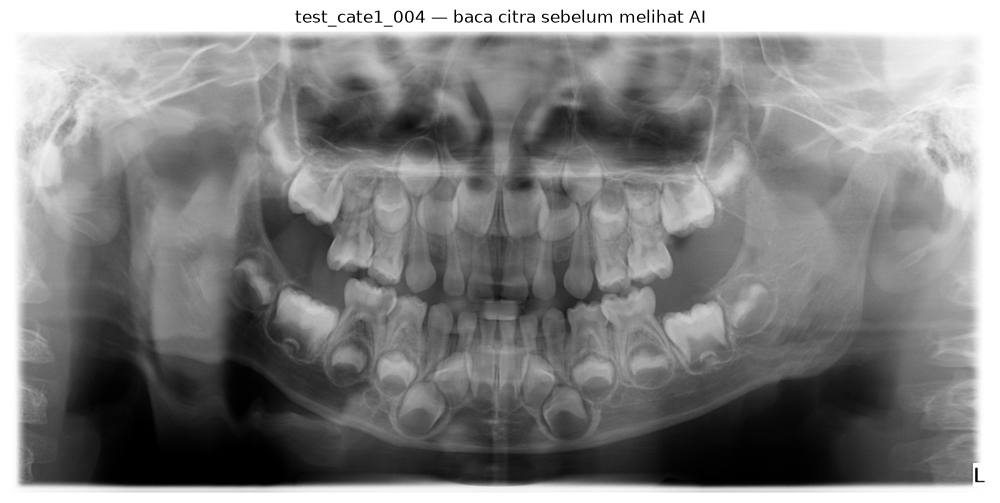

In [15]:
if "load_case" not in globals() or "CASE_ID" not in globals():
    raise RuntimeError("Urutan sel belum siap. Pilih Runtime → Run all.")

image_rgb, case_info = load_case(CASE_ID)
show_case_without_ai(image_rgb, CASE_ID)

### 🩺 Diskusikan — Catatan Temuan Mandiri Sebelum Melihat Keluaran AI

Diskusikan hasil pembacaan radiograf Anda bersama rekan kelompok:

1. Tuliskan **maksimal tiga observasi visual objektif** (tanda radiografis murni) dan **satu hal yang masih meragukan** (*uncertainty*).
2. Bedakan secara tegas antara **apa yang tampak secara fisik pada citra** (misalnya: radiolusen berbatas jelas pada mahkota gigi 75) dan **interpretasi diagnostik klinis** (misalnya: karies dentin profunda).
3. Setelah Anda dan rekan selesai mendokumentasikan observasi mandiri, barulah kita melangkah ke bagian analisis model AI.

> **Wawasan Klinis — Mencegah Bias Otomatisasi (*Automation Bias*):**  
> Alur kerja ini dirancang untuk melatih kita terhindar dari *automation bias*, yakni kecenderungan psikologis klinisi untuk secara tidak sadar mengubah, meragukan, atau melunakkan penilaian profesionalnya sendiri semata-mata karena telah melihat kotak prediksi yang disodorkan oleh komputer.

---
## 2. Tiga Tugas Utama Visi Komputer dalam Radiologi (Menit 15–45)

Dalam rekayasa kecerdasan artifisial untuk citra radiografi, permasalahan umumnya dikelompokkan ke dalam tiga jenis tugas utama (*computer vision tasks*):

| Jenis Tugas (*Task*) | Bentuk Keluaran | Pertanyaan Klinis yang Dijawab | Keterbatasan Representasi |
|---|---|---|---|
| **Klasifikasi** (*Classification*) | Satu atau beberapa label kategori untuk keseluruhan citra | *"Kelainan apa yang tampak pada citra ini?"* | Hanya mengenali keberadaan kelainan secara global tanpa menunjukkan lokasi spasialnya. |
| **Deteksi Objek** (*Object Detection*) | Label kelainan + skor keyakinan + kotak pembatas (*bounding box*) | *"Kelainan apa yang terdeteksi dan di mana perkiraan posisinya?"* | Kotak geometris berbentuk persegi panjang, tidak mengikuti kontur batas biologis lesi yang ireguler. |
| **Segmentasi** (*Segmentation*) | Masker piksel (*pixel mask*) yang menandai area objek secara tepat | *"Piksel mana saja yang secara tepat menyusun batas objek atau lesi tersebut?"* | Membutuhkan proses pelabelan data acuan yang sangat teliti, mahal, serta tetap rentan variasi antar-anotator. |

Model detektor yang kita gunakan pada sesi ini bekerja dengan memindai citra dan menghasilkan ratusan kandidat kotak prediksi. Parameter `CONF_THRESHOLD` bertugas menyaring kandidat tersebut berdasarkan **skor keyakinan model**, kemudian algoritma *Non-Maximum Suppression* (NMS) akan mengeliminasi kotak-kotak berlebih yang saling bertumpuk pada satu lesi yang sama.

> **Peringatan Penting:** Besaran skor model ini murni merupakan hasil perhitungan matematis algoritma berdasarkan kecocokan pola visual pada data latihnya. Jangan pernah menyamakan skor model ini dengan persentase kepastian diagnosis atau tingkat risiko riil pada seorang pasien.

### 🩺 Latihan Pemahaman Konsep (3 Menit)

Pasangkan kebutuhan klinis berikut dengan jenis tugas AI yang paling tepat:

1. Menilai apakah sebuah citra OPG layak baca atau harus diulang akibat adanya pergerakan pasien (*motion artifact*).
2. Menandai perkiraan lokasi lesi periapikal pada rahang bawah dengan kotak pembatas.
3. Menggambarkan kontur batas anatomis kanalis mandibula piksel demi piksel untuk keperluan perencanaan implan gigi.

<details>
<summary><b>Klik di sini untuk melihat pembahasan setelah berdiskusi</b></summary>

1. **Klasifikasi (*Classification*):** Menghasilkan label kategori tunggal untuk keseluruhan citra (misalnya: *layak baca* vs *tidak layak baca*).
2. **Deteksi Objek (*Object Detection*):** Menghasilkan koordinat kotak pembatas (*bounding box*) yang melingkupi area kelainan beserta label dan skornya.
3. **Segmentasi (*Segmentation*):** Menentukan status kelas pada setiap piksel individual sehingga mampu mengikuti batas anatomis yang rumit secara presisi.

*Refleksi:* Mengetahui nama tugas AI hanyalah langkah awal. Seberapa bermanfaat model tersebut di ruang praktik sangat ditentukan oleh kualitas data latih, ketepatan batasan label, serta validasi klinis eksternal yang ketat di populasi lokal kita.
</details>

### Ruang Label (*Label Space*): "Kamus" Kelainan yang Dikenali Model

Sebuah model AI hanya mampu mengenali dan memprediksi kelas kelainan yang telah dipelajari di dalam ruang labelnya (*label space*). Model tidak memiliki pemahaman di luar "kamus" yang dipelajarinya tersebut.

Pada praktikum hari ini, kita menghadapi perbedaan ruang label yang nyata antara data acuan dan model AI yang kita uji:
- **Anotasi dataset acuan (*ground truth*):** Mencakup karies, periodontitis periapikal, pit/fisur dalam, pulpitis, kelainan tumbuh kembang gigi, dan kategori lainnya.
- **Model detektor eksternal:** Hanya dilatih untuk mengenali tiga kelas deteksi: `caries` (karies), `periapical_lesion` (lesi periapikal), dan `impacted_tooth` (gigi impaksi).

Oleh sebab itu, dalam mengevaluasi kinerja model:
- Label **karies** ↔ `caries` memiliki kesetaraan klinis langsung sehingga dapat dibandingkan secara adil.
- Label **periodontitis periapikal** ↔ `periapical_lesion` disetarakan secara operasional untuk keperluan praktikum, dengan catatan bahwa cakupan definisi klinis keduanya dapat memiliki sedikit perbedaan.
- Temuan gigi impaksi (`impacted_tooth`), pit/fisur dalam, pulpitis, serta kelainan tumbuh kembang ditandai sebagai **"di luar cakupan skema label evaluasi ini"**.
- Kelas kelainan yang tidak saling kompatibel **tidak boleh dipaksakan** masuk ke dalam perhitungan True Positive (TP), False Positive (FP), maupun False Negative (FN), agar tidak mendistorsi hasil evaluasi performa model.

---
## 3. Transparansi Model: *Dataset Card*, *Model Card*, dan Asal-Usul Data (Menit 45–75)

### Ringkasan *Dataset Card* (Data Acuan Publik)

Empat kasus radiograf yang kita telaah hari ini diambil dari kelompok data uji (**Test**) pada dataset terbuka
[Children’s Dental Panoramic Radiographs Dataset](https://springernature.figshare.com/articles/dataset/Children_s_Dental_Panoramic_Radiographs_Dataset/21621705).
Rincian metodologi pengumpulan data dari 100 pasien anak usia 2–13 tahun, protokol anonimisasi, persetujuan tindakan (*informed consent*), serta izin kaji etik diuraikan secara transparan dalam publikasi resmi di [Scientific Data (Nature Portfolio)](https://www.nature.com/articles/s41597-023-02237-5).

Berkas dataset dirilis di bawah lisensi domain publik CC0, sedangkan artikel ilmiah pendampingnya menggunakan lisensi CC BY 4.0. Seluruh metadata rujukan, tautan DOI, dan sidik jari digital (SHA-256) untuk memastikan keaslian berkas tercatat secara rapi di dalam berkas manifes repositori ini.

**Prinsip Pembagian Data (*Train / Validation / Test Split*):**
- **Data Latih (*Train*):** Digunakan oleh algoritma untuk mempelajari pola visual dan mengoptimalkan parameter bobot model.
- **Data Validasi (*Validation*):** Digunakan oleh pengembang untuk menyetel konfigurasi (*hyperparameters*) dan memilih arsitektur terbaik selama proses eksperimen.
- **Data Uji (*Test*):** Disimpan secara terpisah dan baru diuji pada tahap akhir untuk mengukur performa model pada data yang belum pernah dilihat sebelumnya.

> Empat kasus uji ini tidak pernah digunakan untuk melatih model deteksi yang kita uji di kelas. Perlu diingat bahwa ukuran sampel empat kasus ini semata-mata ditujukan sebagai bahan latihan audit klinis, dan tentu terlalu kecil untuk menarik kesimpulan mengenai performa model pada populasi pasien anak secara umum.

### ▶ Jalankan — Menampilkan Anotasi Acuan Publik (*Ground Truth*) dan Metadata Kasus Aktif

Sel di bawah ini mengekstrak dan menampilkan metadata kasus aktif beserta seluruh kotak anotasi acuan (*ground truth*) yang diberikan oleh pakar dari dataset publik.

In [16]:
annotations = _case_annotations(case_info)
print("Kasus:", CASE_ID)
print("Ukuran citra (H, W, C):", image_rgb.shape)
print("Jumlah anotasi acuan:", len(annotations))
for idx, item in enumerate(annotations, start=1):
    label = item.get("name") or item.get("label") or "kelainan"
    box = item.get("box_2d") or item.get("bbox")
    print(f"  {idx}. Label: {label:18s} | Box [ymin, xmin, ymax, xmax]: {box}")

Kasus: test_cate1_004
Ukuran citra (H, W, C): (942, 2000, 3)
Jumlah anotasi acuan: 8
  1. Label: kelainan           | Box [ymin, xmin, ymax, xmax]: None
  2. Label: kelainan           | Box [ymin, xmin, ymax, xmax]: None
  3. Label: kelainan           | Box [ymin, xmin, ymax, xmax]: None
  4. Label: kelainan           | Box [ymin, xmin, ymax, xmax]: None
  5. Label: kelainan           | Box [ymin, xmin, ymax, xmax]: None
  6. Label: kelainan           | Box [ymin, xmin, ymax, xmax]: None
  7. Label: kelainan           | Box [ymin, xmin, ymax, xmax]: None
  8. Label: kelainan           | Box [ymin, xmin, ymax, xmax]: None


### Ringkasan *Model Card* (Model Eksternal yang Diaudit)

Kita mengaudit model detektor berformat `best.onnx` dari repositori terbuka
[liodon-ai/dental-panoramic-detector](https://huggingface.co/liodon-ai/dental-panoramic-detector),
dengan versi yang dikunci secara spesifik pada nomor revisi `8bef2036b099e80e51f93f24de4b0c0edd366256`.

**Spesifikasi Teknis Model:**
- **Nilai SHA-256 Wajib:** `4cee38b54203634d895ed30a8910f5d7c4cefe22b18f9116b5561d9dd6e83a71`
- **Dimensi Citra Masukan (*Input*):** RGB 640×640 piksel menggunakan metode *letterbox* (rasio aspek asli tetap dipertahankan dengan menambahkan bantalan abu-abu netral).
- **Lingkungan Eksekusi (*Runtime*):** ONNX Runtime 1.27.0 pada prosesor CPU standar.
- **Ambang Batas Keyakinan (*Confidence Threshold*):** Rekomendasi resmi dari pengembang model adalah 0,45. Dalam praktikum ini, kita juga akan menguji nilai ambang 0,25 untuk melihat dinamika perubahannya.
- **Ambang Batas NMS IoU:** Dikunci pada nilai 0,35 untuk menyaring kotak deteksi yang saling bertumpuk.
- **Aspek Lisensi dan Legalitas:** Halaman *model card* mencantumkan lisensi CC BY-NC 4.0 (khusus non-komersial), sedangkan metadata internal yang tertanam pada berkas ONNX menyebutkan lisensi Ultralytics AGPL-3.0. Ketidaksesuaian klausul lisensi seperti ini merupakan contoh nyata pentingnya audit aspek legal sebelum sebuah model AI diadopsi di lingkungan pelayanan kesehatan.

Berkas bobot model ini sengaja tidak disertakan langsung di dalam repositori proyek, melainkan diunduh saat dibutuhkan khusus untuk keperluan latihan akademik non-komersial. Asal-usul data pelatihannya (*provenance*) serta kesesuaiannya terhadap populasi OPG anak merupakan aspek kritis yang wajib kita audit secara cermat, bukan dipercaya begitu saja.

### ▶ Jalankan — Konfigurasi Model ONNX, URL Repositori, dan Skema Warna Deteksi

Mendefinisikan pustaka inferensi `onnxruntime`, versi revisi model Hugging Face yang terpatok (*pinned*), nilai hash SHA-256 acuan untuk audit integritas, kamus nama kelas standar, serta warna penanda visual (*bounding box*) untuk setiap kelas patologis.

In [17]:
import ast
import importlib.metadata

import onnxruntime as ort

MODEL_REVISION = "8bef2036b099e80e51f93f24de4b0c0edd366256"
MODEL_SHA256 = "4cee38b54203634d895ed30a8910f5d7c4cefe22b18f9116b5561d9dd6e83a71"
MODEL_URL = (
    "https://huggingface.co/liodon-ai/dental-panoramic-detector/resolve/"
    f"{MODEL_REVISION}/best.onnx?download=true"
)
MODEL_PATH = Path(tempfile.gettempdir()) / f"dental_detector_{MODEL_REVISION[:8]}.onnx"
DEFAULT_CLASS_NAMES = {0: "caries", 1: "periapical_lesion", 2: "impacted_tooth"}
BOX_COLORS = {
    "caries": "#ff3b30",
    "periapical_lesion": "#ff9500",
    "impacted_tooth": "#00a6fb",
}

### ▶ Jalankan — Modul Pengunduhan dan Verifikasi Integritas Model ONNX (`_download_verified_model`)

Fungsi ini mengunduh berkas model `best.onnx` dari Hugging Face secara aman, memeriksa kesesuaian nilai *hash* SHA-256 secara ketat, dan menolak model jika berkas tidak identik dengan versi yang diaudit.

In [18]:
def _download_verified_model():
    temporary = MODEL_PATH.with_suffix(".onnx.part")
    if MODEL_PATH.exists():
        actual = _sha256(MODEL_PATH)
        if actual == MODEL_SHA256:
            print("Model terverifikasi dari cache:", actual[:12] + "…")
            return MODEL_PATH
        MODEL_PATH.unlink()
        print("Model cache dihapus karena checksum tidak cocok.")
    if temporary.exists():
        temporary.unlink()

    print("Mengunduh model ONNX terpatok (sekitar 11 MB)...")
    request = urllib.request.Request(MODEL_URL, headers={"User-Agent": "Dental-AI-Lab/1.0"})
    try:
        with urllib.request.urlopen(request, timeout=120) as response:
            with open(temporary, "wb") as output:
                while True:
                    chunk = response.read(1024 * 1024)
                    if not chunk:
                        break
                    output.write(chunk)
    except (OSError, urllib.error.URLError) as error:
        if temporary.exists():
            temporary.unlink()
        raise RuntimeError(
            "Unduhan model gagal atau timeout. File parsial dihapus. "
            "Periksa koneksi, lalu jalankan ulang sel ini."
        ) from error

    actual = _sha256(temporary)
    if actual != MODEL_SHA256:
        temporary.unlink()
        raise RuntimeError(
            "Checksum model tidak cocok. File unduhan dihapus dan tidak dimuat. "
            f"Diperoleh {actual}; diharapkan {MODEL_SHA256}."
        )
    temporary.replace(MODEL_PATH)
    print("Checksum model cocok:", actual)
    return MODEL_PATH

### ▶ Jalankan — Modul Pembacaan Nama Kelas dari Metadata Model (`_parse_class_names`)

Fungsi ini membaca pemetaan ID kelas ke nama kelainan langsung dari metadata tertanam di dalam berkas model ONNX (`custom_metadata_map`).

In [19]:
def _parse_class_names(metadata):
    raw = metadata.get("names") if metadata else None
    if not raw:
        return DEFAULT_CLASS_NAMES.copy()
    try:
        parsed = ast.literal_eval(raw)
        return {int(key): str(value) for key, value in parsed.items()}
    except (ValueError, SyntaxError, AttributeError):
        print("Nama kelas metadata tidak terbaca; memakai nama dari model card.")
        return DEFAULT_CLASS_NAMES.copy()

### ▶ Jalankan — Modul Inisialisasi Sesi Inferensi Detektor ONNX (`load_detector`)

Fungsi ini menginisialisasi `InferenceSession` ONNX Runtime dengan *CPUExecutionProvider* deterministik satu *thread*, mengekstrak metadata kelas, dan memvalidasi ulang hash integritas model.

In [20]:
def load_detector():
    if importlib.metadata.version("onnxruntime") != "1.27.0":
        raise RuntimeError(
            "Versi onnxruntime bukan 1.27.0. Jalankan kembali sel persiapan, "
            "restart session bila diminta, lalu ulangi."
        )
    model_path = _download_verified_model()
    options = ort.SessionOptions()
    options.intra_op_num_threads = 1
    options.inter_op_num_threads = 1
    options.execution_mode = ort.ExecutionMode.ORT_SEQUENTIAL
    options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    session = ort.InferenceSession(
        str(model_path), sess_options=options, providers=["CPUExecutionProvider"]
    )
    metadata = session.get_modelmeta().custom_metadata_map
    detector = {
        "session": session,
        "input_name": session.get_inputs()[0].name,
        "names": _parse_class_names(metadata),
        "metadata": metadata,
        "sha256": _sha256(model_path),
    }
    if detector["sha256"] != MODEL_SHA256:
        raise RuntimeError("Checksum berubah setelah model dimuat; inferensi dihentikan.")
    return detector

### ▶ Jalankan — Modul Pra-Pemrosesan Letterbox Citra Masukan (`_letterbox`)

Fungsi ini mengubah ukuran citra OPG ke dimensi target model ($640 \times 640$) dengan mempertahankan rasio aspek asli menggunakan *padding* abu-abu netral (nilai 114), serta mengonversi piksel ke format tensor terstandarisasi.

In [21]:
def _letterbox(image_rgb, size=640):
    height, width = image_rgb.shape[:2]
    scale = min(size / width, size / height)
    resized_width = int(round(width * scale))
    resized_height = int(round(height * scale))
    resized = cv2.resize(
        image_rgb, (resized_width, resized_height), interpolation=cv2.INTER_LINEAR
    )
    pad_x = size - resized_width
    pad_y = size - resized_height
    left = pad_x // 2
    top = pad_y // 2
    canvas = np.full((size, size, 3), 114, dtype=np.uint8)
    canvas[top:top + resized_height, left:left + resized_width] = resized
    geometry = {
        "scale": scale,
        "left": left,
        "top": top,
        "resized_width": resized_width,
        "resized_height": resized_height,
        "original_width": width,
        "original_height": height,
        "size": size,
    }
    tensor = canvas.astype(np.float32) / 255.0
    tensor = np.transpose(tensor, (2, 0, 1))[None, ...]
    return tensor, geometry

### ▶ Jalankan — Modul Penataan Keluaran Tensor Raw Model (`_output_rows`)

Fungsi ini menjalankan sesi ONNX Runtime pada tensor masukan dan menata matriks prediksi agar setiap baris mewakili satu kandidat deteksi $[x, y, w, h, \text{skor}_0, \dots]$.

In [22]:
def _output_rows(detector, tensor):
    raw = detector["session"].run(
        None, {detector["input_name"]: tensor.astype(np.float32)}
    )[0]
    rows = np.squeeze(raw)
    if rows.ndim != 2:
        raise RuntimeError(f"Shape output model tidak dikenali: {raw.shape}")
    if rows.shape[0] <= 100 and rows.shape[1] > rows.shape[0]:
        rows = rows.T
    if rows.shape[1] < 5:
        raise RuntimeError(f"Output tidak memuat skor kelas: {rows.shape}")
    return rows

### ▶ Jalankan — Modul Transformasi Koordinat Prediksi ke Skala Asli (`_xywh_to_original`)

Fungsi ini membalikkan efek penskalaan dan *padding letterbox*, mentranslasikan koordinat pusat-lebar-tinggi ($cx, cy, w, h$) kembali ke batas koordinat piksel asli $[x_1, y_1, x_2, y_2]$.

In [23]:
def _xywh_to_original(xywh, geometry):
    center_x, center_y, width, height = [float(value) for value in xywh]
    x1 = (center_x - width / 2 - geometry["left"]) / geometry["scale"]
    y1 = (center_y - height / 2 - geometry["top"]) / geometry["scale"]
    x2 = (center_x + width / 2 - geometry["left"]) / geometry["scale"]
    y2 = (center_y + height / 2 - geometry["top"]) / geometry["scale"]
    x1 = np.clip(x1, 0, geometry["original_width"])
    x2 = np.clip(x2, 0, geometry["original_width"])
    y1 = np.clip(y1, 0, geometry["original_height"])
    y2 = np.clip(y2, 0, geometry["original_height"])
    return [float(x1), float(y1), float(x2), float(y2)]

### ▶ Jalankan — Modul Perhitungan Luas Irisan per Gabungan (*Intersection over Union* / IoU) (`_box_iou`)

Fungsi matematika untuk menghitung rasio tumpang tindih (*overlap*) antara dua kotak pembatas koordinat $[x_1, y_1, x_2, y_2]$.

In [24]:
def _box_iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = [float(value) for value in box_a]
    bx1, by1, bx2, by2 = [float(value) for value in box_b]
    intersection_width = max(0.0, min(ax2, bx2) - max(ax1, bx1))
    intersection_height = max(0.0, min(ay2, by2) - max(ay1, by1))
    intersection = intersection_width * intersection_height
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - intersection
    return intersection / union if union > 0 else 0.0

### ▶ Jalankan — Modul Penyaringan Redundansi Kotak (*Classwise Non-Maximum Suppression*) (`_classwise_nms`)

Fungsi NMS berbasis kelas untuk mengeliminasi kotak-kotak deteksi ganda yang tumpang tindih pada lesi yang sama dan hanya menyisakan kandidat dengan skor keyakinan tertinggi.

In [25]:
def _classwise_nms(candidates, iou_threshold):
    kept = []
    class_ids = sorted({candidate["class_id"] for candidate in candidates})
    for class_id in class_ids:
        remaining = sorted(
            [candidate for candidate in candidates if candidate["class_id"] == class_id],
            key=lambda candidate: candidate["score"],
            reverse=True,
        )
        while remaining:
            best = remaining.pop(0)
            kept.append(best)
            remaining = [
                candidate for candidate in remaining
                if _box_iou(best["bbox_xyxy"], candidate["bbox_xyxy"]) <= iou_threshold
            ]
    return sorted(kept, key=lambda candidate: candidate["score"], reverse=True)

### ▶ Jalankan — Modul Pipeline Inferensi Deteksi Lengkap (`predict_boxes`)

Fungsi utama yang merangkai pra-pemrosesan citra, eksekusi model ONNX, penyaringan ambang keyakinan (*confidence threshold*), penyesuaian koordinat, dan penyaringan NMS.

In [26]:
def predict_boxes(detector, image_rgb, conf_threshold=0.25, nms_iou=0.35):
    if detector is None:
        raise RuntimeError("Detektor belum tersedia; muat model terlebih dahulu.")
    if not 0.0 <= conf_threshold <= 1.0:
        raise ValueError("conf_threshold harus berada di antara 0 dan 1.")
    tensor, geometry = _letterbox(image_rgb, size=640)
    rows = _output_rows(detector, tensor)
    class_scores = rows[:, 4:]
    class_ids = np.argmax(class_scores, axis=1)
    scores = class_scores[np.arange(len(rows)), class_ids]
    candidates = []
    for row, class_id, score in zip(rows, class_ids, scores):
        if float(score) < conf_threshold:
            continue
        box = _xywh_to_original(row[:4], geometry)
        if box[2] <= box[0] or box[3] <= box[1]:
            continue
        candidates.append(
            {
                "class_id": int(class_id),
                "label": detector["names"].get(int(class_id), f"class_{class_id}"),
                "score": float(score),
                "bbox_xyxy": box,
            }
        )
    return _classwise_nms(candidates, nms_iou)

### ▶ Jalankan — Modul Penyeragaman Format Prediksi Deteksi (`_normalize_prediction`)

Fungsi pembantu untuk memastikan setiap elemen hasil deteksi memiliki kunci kamus, tipe data numerik, dan struktur koordinat kotak yang seragam.

In [27]:
def _normalize_prediction(prediction):
    result = dict(prediction)
    result["bbox_xyxy"] = [
        float(value) for value in result.get("bbox_xyxy", result.get("box", []))
    ]
    result["score"] = float(result["score"])
    result["label"] = str(result["label"])
    if "class_id" in result:
        result["class_id"] = int(result["class_id"])
    else:
        reverse_names = {value: key for key, value in DEFAULT_CLASS_NAMES.items()}
        result["class_id"] = reverse_names.get(result["label"], -1)
    return result

### ▶ Jalankan — Modul Pemuatan Data Prediksi Cadangan (*Fallback Data*) (`load_fallback_predictions`)

Fungsi untuk memuat berkas `precomputed_predictions.json` sebagai data cadangan bila lingkungan komputasi peserta offline atau mengalami kendala pemuatan model ONNX.

In [28]:
def load_fallback_predictions():
    path = _find_asset("precomputed_predictions.json")
    with open(path, encoding="utf-8") as handle:
        data = json.load(handle)
    recorded_hash = data.get("model_sha256")
    if not recorded_hash and isinstance(data.get("model"), dict):
        recorded_hash = data["model"].get("sha256")
    if recorded_hash and recorded_hash != MODEL_SHA256:
        raise RuntimeError("Fallback berasal dari hash model yang berbeda; fallback ditolak.")
    return data

### ▶ Jalankan — Modul Pengambilan Prediksi Cadangan per Kasus dan Ambang (`_fallback_for`)

Fungsi untuk mengekstrak daftar kotak deteksi tersimpan yang sesuai dengan ID kasus dan ambang keyakinan tertentu dari objek data cadangan.

In [29]:
def _fallback_for(data, case_id, threshold):
    predictions_root = data.get("predictions", data.get("cases", data))
    keys = [case_id, case_id.removeprefix("test_"), f"test_{case_id.removeprefix('test_')}"]
    case_block = next((predictions_root[key] for key in keys if key in predictions_root), None)
    if case_block is None:
        raise KeyError(f"Fallback untuk {case_id} tidak tersedia.")
    threshold_keys = [f"{threshold:.2f}", str(threshold), str(round(threshold, 2))]
    result = next((case_block[key] for key in threshold_keys if key in case_block), None)
    if result is None:
        available = ", ".join(sorted(case_block))
        raise KeyError(
            f"Fallback hanya tersedia untuk ambang: {available}. "
            "Gunakan inferensi langsung untuk ambang lain."
        )
    return [_normalize_prediction(item) for item in result]

### ▶ Jalankan — Modul Visualisasi Kotak Deteksi Model pada Radiograf (`show_predictions`)

Fungsi untuk menampilkan citra radiograf panoramik beserta kotak pembatas (*bounding box*) berwarna, label kelas temuan, dan nilai skor keyakinan model.

In [30]:
def show_predictions(image, predictions, title, ax=None):
    created = ax is None
    if created:
        _, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(image)
    for prediction in predictions:
        x1, y1, x2, y2 = prediction["bbox_xyxy"]
        color = BOX_COLORS.get(prediction["label"], "#7b61ff")
        ax.add_patch(
            Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, lw=2, ec=color)
        )
        ax.text(
            x1,
            max(0, y1 - 7),
            f"{prediction['label']} | skor {prediction['score']:.2f}",
            color="white",
            fontsize=8,
            bbox={"facecolor": color, "alpha": 0.85, "pad": 2, "edgecolor": "none"},
        )
    ax.set_title(title)
    ax.axis("off")
    if created:
        plt.show()

### ▶ Jalankan — Modul Terpadu Inferensi Langsung atau Penarikan Data Cadangan (`get_case_predictions`)

Fungsi serbaguna yang memuat kasus OPG lalu secara otomatis melakukan inferensi langsung via ONNX (bila model tersedia) atau mengambil keluaran kanonis tersimpan (bila dalam mode fallback).

In [31]:
def get_case_predictions(case_id, threshold):
    image, case = load_case(case_id)
    detector_value = globals().get("DETECTOR")
    if detector_value is not None:
        predictions = predict_boxes(
            detector_value, image, conf_threshold=threshold, nms_iou=0.35
        )
        source = "INFERENSI LANGSUNG · ONNX terverifikasi"
    else:
        fallback_data = globals().get("FALLBACK_DATA")
        if fallback_data is None:
            raise RuntimeError(
                "Model dan fallback belum tersedia. Jalankan sel pemuatan model."
            )
        predictions = _fallback_for(fallback_data, case_id, threshold)
        source = "FALLBACK TERSIMPAN · hanya untuk diskusi"
    return image, case, predictions, source

print("Helper detektor siap. NMS IoU dikunci pada 0,35.")

Helper detektor siap. NMS IoU dikunci pada 0,35.


### ▶ Jalankan — Mengunduh, Memverifikasi Integritas Berkas, dan Memuat Model ke Memori (CPU)

Sel di bawah ini memuat model detektor ke memori kerja untuk inferensi langsung. Jika jaringan terhambat atau file gagal diunduh, sistem otomatis beralih ke mode data cadangan (*fallback*) sehingga praktikum tetap dapat berjalan lancar.

In [32]:
if "load_detector" not in globals() or "load_fallback_predictions" not in globals():
    raise RuntimeError("Helper model belum siap. Pilih Runtime → Run all.")

try:
    DETECTOR = load_detector()
    FALLBACK_DATA = None
    STATUS_SUMBER = "INFERENSI LANGSUNG · ONNX terverifikasi"
    print("STATUS:", STATUS_SUMBER)
except Exception as error:
    DETECTOR = None
    FALLBACK_DATA = load_fallback_predictions()
    STATUS_SUMBER = "FALLBACK TERSIMPAN · hanya untuk diskusi"
    print("MODEL TIDAK DIMUAT:", error)
    print("STATUS: Beralih otomatis ke FALLBACK TERSIMPAN.")

Model terverifikasi dari cache: 4cee38b54203…
STATUS: INFERENSI LANGSUNG · ONNX terverifikasi


> **Panduan Pemulihan Model:**  
> Jika muncul pesan `MODEL TIDAK DIMUAT`, periksa penyebab teknis yang tercetak pada sel di atas. Jika terjadi *timeout*, periksa koneksi internet Anda lalu jalankan kembali sel pemuatan model. Jika terjadi ketidakcocokan *checksum*, jangan pernah mengubah nilai acuan di dalam kode; unduh ulang salinan berkas resmi dari nomor revisi yang telah ditentukan. Mode *fallback* disiapkan agar kegiatan diskusi visual tetap dapat berjalan lancar ketika koneksi terputus, namun berkas cadangan ini **tidak dapat** digunakan untuk menghasilkan visualisasi *heatmap* baru secara interaktif.

### ✅ Checkpoint dan Istirahat Sejenak (Menit 75–90)

Sebelum beristirahat sejenak, diskusikan tiga pertanyaan refleksi ini bersama rekan kelompok Anda:
1. Apa saja kelainan yang tercakup di dalam ruang label (*label space*) model deteksi yang kita gunakan?
2. Mengapa hasil pengujian pada empat kasus OPG anak ini belum dapat dijadikan bukti keandalan performa model pada populasi umum?
3. Mengapa nilai skor keyakinan model berbeda secara mendasar dari tingkat kepastian diagnosis dokter gigi spesialis radiologi?

---
## 4. Inferensi Deteksi dan Pengaruh Ambang Batas Keyakinan (Menit 90–115)

Parameter `CONF_THRESHOLD` menentukan batas minimal skor keyakinan yang harus dicapai sebuah kotak prediksi agar dipertahankan sebelum diproses oleh tahapan penapisan NMS.

Dinamika pemilihan nilai ambang batas:
- **Menurunkan ambang batas** (misalnya menjadi 0,25) akan meloloskan lebih banyak kotak kandidat. Hal ini berpotensi menemukan kelainan yang samar, namun dengan risiko memunculkan lebih banyak deteksi keliru (*false positive*).
- **Menaikkan ambang batas** (misalnya menjadi 0,45) membuat model lebih selektif sehingga tampilan citra terlihat lebih bersih. Namun, terdapat konsekuensi klinis yang berisiko: lesi nyata yang berukuran kecil atau berdensitas rendah bisa terlewat dan tidak terdeteksi (*false negative*).

### ✏ Ubah — Menentukan Ambang Batas Keyakinan (*Confidence Threshold*)

Ubah nilai ambang batas keyakinan berikut. Coba jalankan dengan nilai default `0.25`, kemudian nanti bandingkan dengan ambang `0.45` untuk melihat perubahan jumlah kotak deteksi yang ditampilkan model.

In [33]:
CONF_THRESHOLD = 0.25

### ▶ Jalankan — Mengeksekusi Inferensi Deteksi pada Kasus yang Aktif

Sel di bawah ini menjalankan proses deteksi pada citra kasus aktif berdasarkan ambang batas `CONF_THRESHOLD` yang ditentukan, lalu menampilkan visualisasi temuan kotak pembatas.

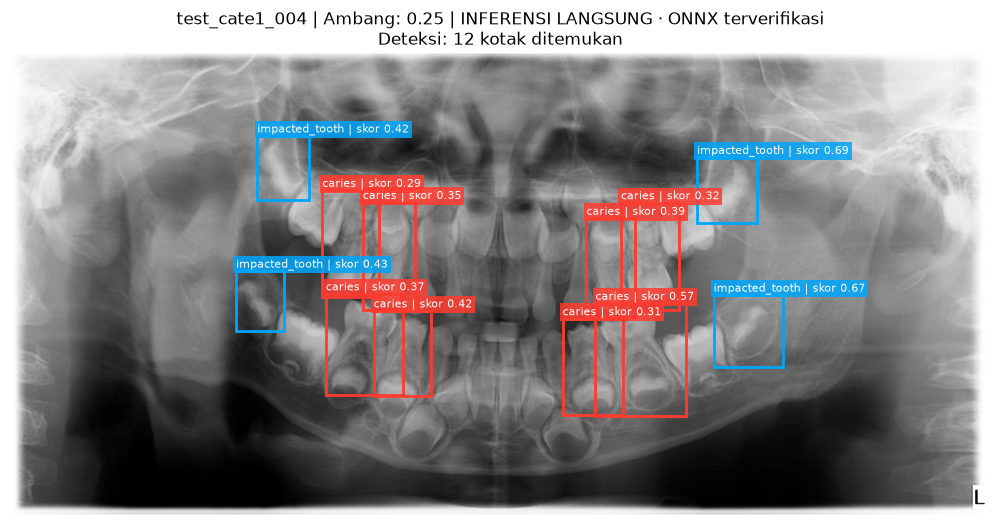

In [34]:
if not all(name in globals() for name in ("get_case_predictions", "CASE_ID", "CONF_THRESHOLD")):
    raise RuntimeError("Urutan sel belum lengkap. Pilih Runtime → Run all.")

image_rgb, case_info, predictions, source = get_case_predictions(
    CASE_ID, CONF_THRESHOLD
)
title = (
    f"{CASE_ID} | Ambang: {CONF_THRESHOLD:.2f} | {source}\n"
    f"Deteksi: {len(predictions)} kotak ditemukan"
)
show_predictions(image_rgb, predictions, title)

### ▶ Jalankan — Membandingkan Visualisasi Deteksi Ambang 0,25 dengan Ambang Rekomendasi 0,45

Sel di bawah ini menampilkan perbandingan visual langsung antara ambang sensitif `0.25` dengan ambang batas rekomendasi resmi `0.45` pada kasus yang sedang aktif.

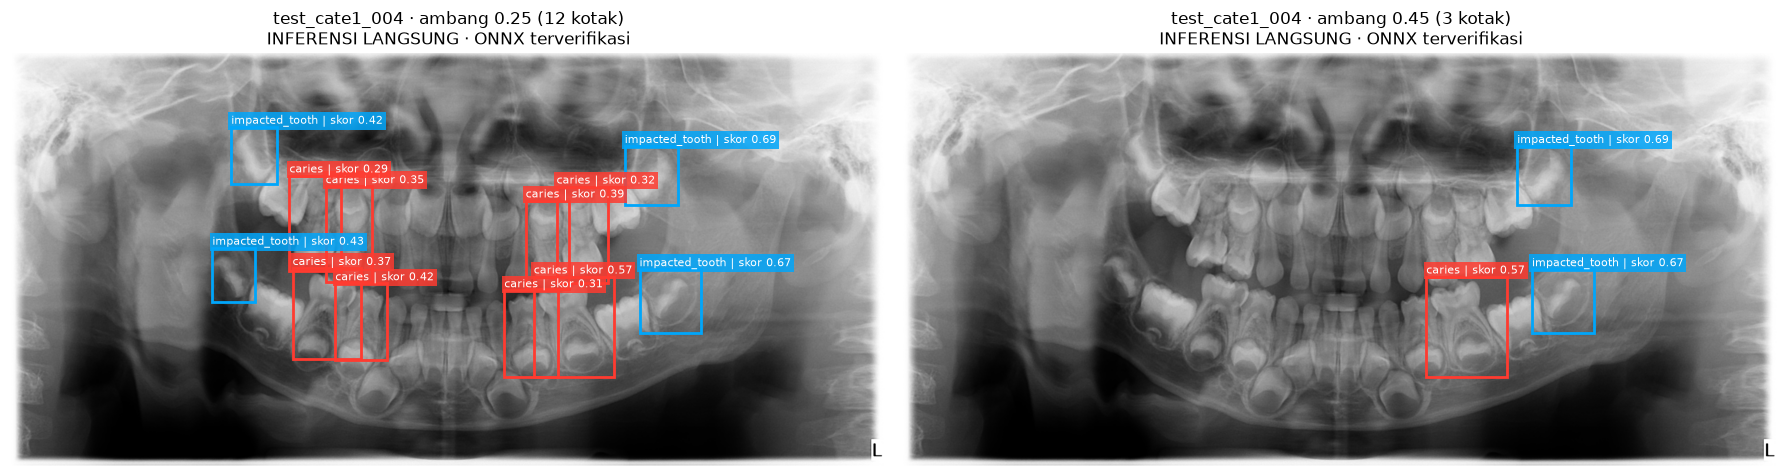

Perbandingan jumlah kotak (test_cate1_004): 0.25=12 vs 0.45=3


In [35]:
comparison = []
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, threshold in zip(axes, [0.25, 0.45]):
    _, _, preds, src = get_case_predictions(CASE_ID, threshold)
    comparison.append((threshold, len(preds)))
    title = f"{CASE_ID} · ambang {threshold:.2f} ({len(preds)} kotak)\n{src}"
    show_predictions(image_rgb, preds, title, ax=ax)
plt.tight_layout()
plt.show()
print(f"Perbandingan jumlah kotak ({CASE_ID}): 0.25={comparison[0][1]} vs 0.45={comparison[1][1]}")

### ▶ Jalankan — Audit Visual Hasil Deteksi pada Empat Kasus Uji

Sel di bawah ini melakukan penapisan visual pada seluruh empat kasus uji wajib OPG anak untuk mengidentifikasi keberhasilan, keterbatasan, dan potensi kesalahan deteksi model AI pada ambang `0.25`.

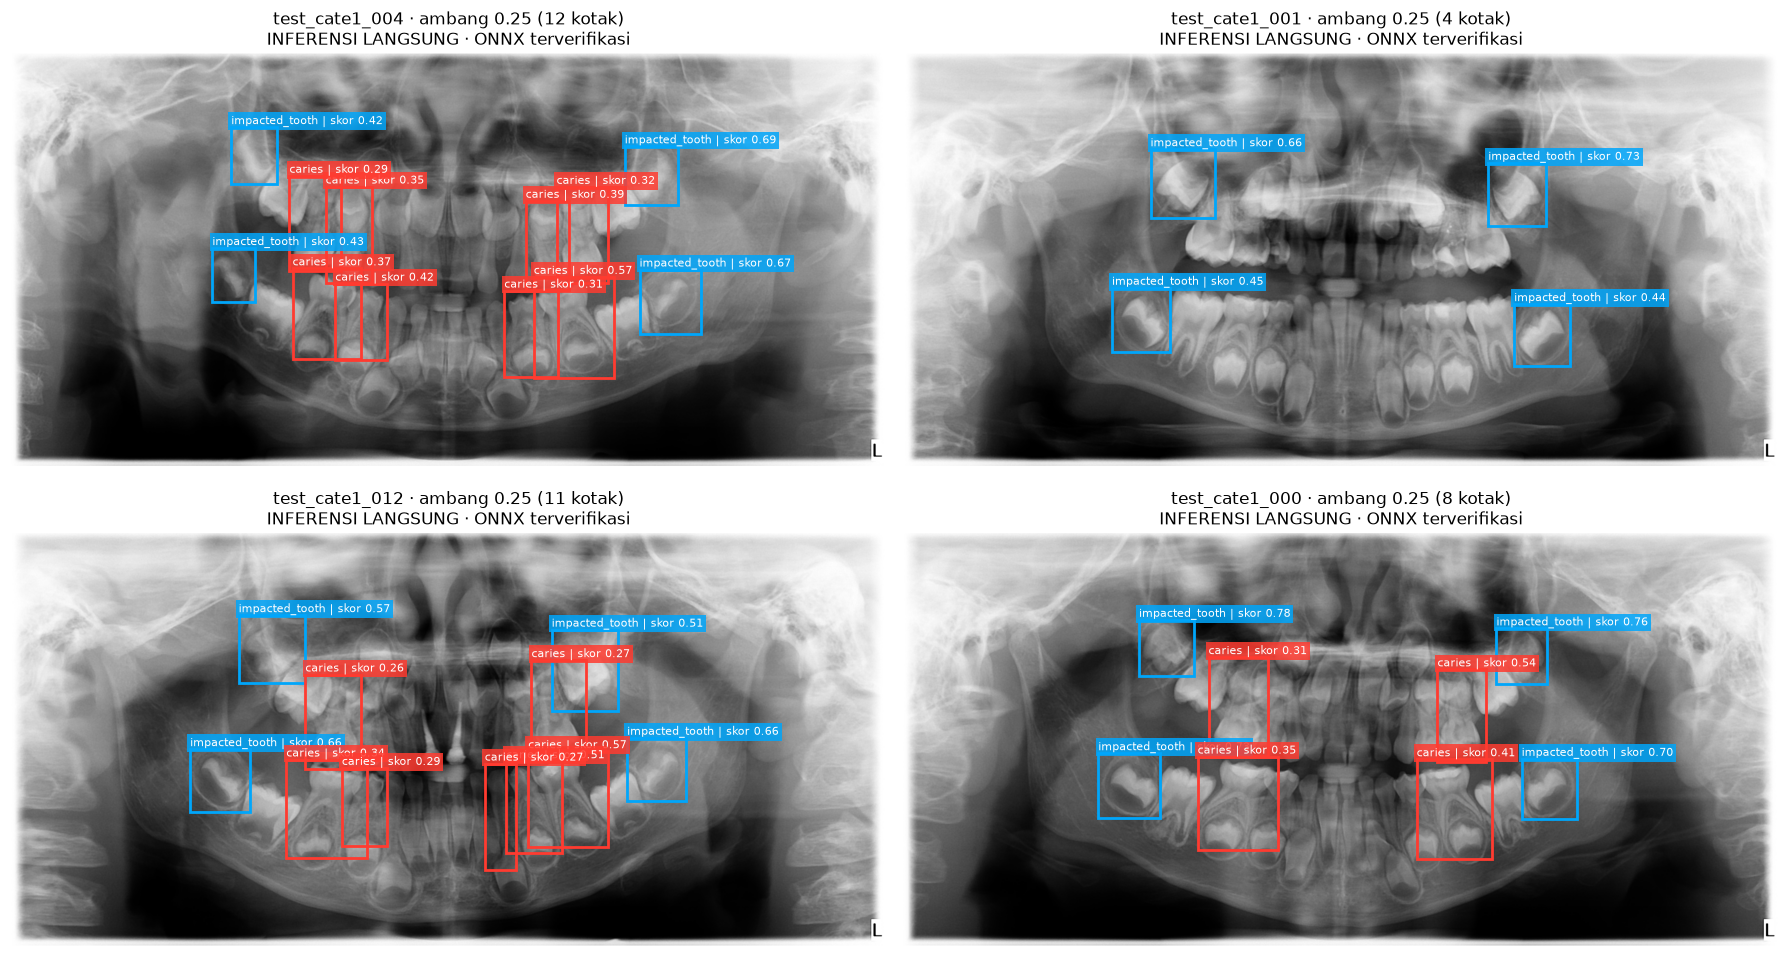

In [36]:
AUDIT_CASES = [
    "test_cate1_004",  # deteksi parsial
    "test_cate1_001",  # periapikal terlewat
    "test_cate1_012",  # karies oklusal
    "test_cate1_000",  # label acuan "other"
]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for ax, case_id in zip(axes.flat, AUDIT_CASES):
    image, _, preds, src = get_case_predictions(case_id, 0.25)
    title = f"{case_id} · ambang 0.25 ({len(preds)} kotak)\n{src}"
    show_predictions(image, preds, title, ax=ax)
plt.tight_layout()
plt.show()

### ▶ Jalankan — Galeri Kanonis (Hanya Aktif Saat Mode FALLBACK)

Sel di bawah ini hanya aktif apabila praktikum berada dalam mode cadangan (*fallback*), menampilkan galeri keluaran kanonis perbandingan ambang 0,25 dan 0,45 untuk keperluan diskusi kelas.

In [37]:
if DETECTOR is None:
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    for col_idx, case_id in enumerate(AUDIT_CASES):
        image, _ = load_case(case_id)
        for row_idx, threshold in enumerate([0.25, 0.45]):
            ax = axes[row_idx, col_idx]
            preds = _fallback_for(FALLBACK_DATA, case_id, threshold)
            title = f"{case_id} | ambang {threshold:.2f} ({len(preds)} kotak)"
            show_predictions(image, preds, title, ax=ax)
    plt.suptitle("Galeri Kanonis Output Model (Mode Cadangan)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    print("Galeri kanonis ditampilkan dari berkas fallback tersimpan.")
else:
    print("Mode inferensi langsung aktif — galeri kanonis dilewati.")

Mode inferensi langsung aktif — galeri kanonis dilewati.


### 🩺 Diskusikan — Dampak Perubahan Ambang Batas terhadap Temuan Radiografis

Amati perbandingan visual pada sel kode di atas dan diskusikan poin-poin berikut bersama rekan Anda:

1. **Efek Penapisan Kotak:** Kotak prediksi mana saja yang menghilang ketika nilai ambang dinaikkan dari 0,25 menjadi 0,45? Menurut penilaian klinis Anda, apakah kotak yang menghilang tersebut merupakan kelainan patologis sungguhan atau sekadar artefak non-lesi?
2. **Kesesuaian Anatomis vs Skor:** Apakah kotak prediksi yang memiliki skor keyakinan tertinggi selalu berada pada lokasi yang paling logis secara anatomi dentomaksilofasial?
3. **Ketidaksesuaian Ruang Label pada Kasus `test_cate1_000`:** Pada kasus ini, anotasi dataset publik hanya mencatat kategori kelainan "lainnya". Ketika model menampilkan kotak prediksi karies pada gigi tertentu, apakah prediksi tersebut bisa langsung divonis sebagai alarm palsu (*false positive*)? Tentu **tidak serta-merta demikian**, karena dataset acuan memang tidak menyediakan anotasi karies pada kasus tersebut.
4. **Analisis Negatif Palsu pada Kasus `test_cate1_012`:** Cermati apakah model berhasil mendeteksi kedua jenis kelainan yang ada pada citra tersebut. Kegagalan model mendeteksi suatu lesi nyata bukanlah bukti bahwa lesi tersebut tidak ada; temuan tersebut baru sah digolongkan sebagai **False Negative** apabila kelainan yang bersangkutan memang tercakup dalam skema ruang label yang kompatibel.

---
## 5. Audit Performa: Anotasi Acuan vs Prediksi Model dan *Domain Shift* (Menit 115–135)

Untuk mengevaluasi ketepatan deteksi secara komputasi, sebuah kotak prediksi dinyatakan berhasil dipasangkan (*matched*) dengan anotasi acuan jika memiliki **kelas kelainan yang sama** serta memiliki nilai tumpang tindih area **Intersection over Union (IoU) ≥ 0,50**:

- **True Positive (TP):** Kotak prediksi dari kelas yang kompatibel berhasil dipasangkan dengan kotak anotasi acuan pada lokasi anatomis yang bersesuaian.
- **False Positive (FP):** Kotak prediksi dari kelas yang kompatibel muncul pada citra, namun tidak memiliki pasangan pada anotasi acuan (alarm palsu / deteksi keliru).
- **False Negative (FN):** Kotak anotasi acuan dari kelas yang kompatibel ada pada citra, namun model gagal mendeteksinya (lesi terlewat).

> **Peringatan Interpretasi Metrik:** Nilai metrik kuantitatif ini sangat bergantung pada konsistensi batasan anotator, batas ambang IoU yang ditetapkan, serta keselarasan ruang label. Hasil perhitungan ini murni merupakan ukuran keselarasan geometris antara dua set kotak koordinat, bukan tolok ukur mutlak keberhasilan diagnosis dokter di klinik.

### ▶ Jalankan — Konfigurasi Himpunan Label Kompatibel untuk Evaluasi

Menentukan himpunan label patologis yang disepakati bersama antara anotasi acuan dataset publik dengan kamus prediksi model detektor (`caries` dan `periapical_lesion`).

In [38]:
SUPPORTED_LABELS = {"caries", "periapical_lesion"}

### ▶ Jalankan — Modul Normalisasi Teks Anotasi Multibahasa (`_annotation_name`)

Fungsi pembantu untuk menyatukan beragam variasi kunci label (bahasa Inggris, bahasa Indonesia, maupun ID asli) ke dalam teks string terpadu berhuruf kecil.

In [39]:
def _annotation_name(annotation):
    values = [
        annotation.get("label_en"),
        annotation.get("label_english"),
        annotation.get("label_id"),
        annotation.get("label_indonesia"),
        annotation.get("label"),
    ]
    return " | ".join(str(value) for value in values if value).lower()

### ▶ Jalankan — Modul Pemetaan Anotasi Acuan ke Ruang Label Kompatibel (`_mapped_annotation_label`)

Fungsi untuk memetakan nama kelainan dari anotasi dataset ke salah satu dari dua kelas evaluasi (`caries` atau `periapical_lesion`). Bila kelainan berada di luar kedua kelas ini, fungsi menghasilkan `None`.

In [40]:
def _mapped_annotation_label(annotation):
    name = _annotation_name(annotation)
    if "caries" in name or "karies" in name or "龋病" in name:
        return "caries"
    if (
        "periapical" in name
        or "periapikal" in name
        or "apical periodontitis" in name
        or "根尖周炎" in name
    ):
        return "periapical_lesion"
    return None

### ▶ Jalankan — Modul Pencocokan Prediksi dengan Anotasi Acuan Berbasis IoU (`match_predictions`)

Fungsi untuk menghitung matriks kebingungan deteksi (*True Positive*, *False Positive*, *False Negative*) berdasarkan kesamaan label dan ambang tumpang tindih spasial (IoU $\ge 0{,}50$).

In [41]:
def match_predictions(predictions, annotations, iou_threshold=0.50):
    supported_ground_truth = []
    unscorable_ground_truth = []
    for index, annotation in enumerate(annotations):
        mapped = _mapped_annotation_label(annotation)
        item = {
            "index": index,
            "label": mapped,
            "original_label": _annotation_name(annotation),
            "bbox_xyxy": [float(value) for value in annotation["bbox_xyxy"]],
        }
        if mapped is None:
            unscorable_ground_truth.append(item)
        else:
            supported_ground_truth.append(item)

    supported_predictions = []
    unscorable_predictions = []
    for index, prediction in enumerate(predictions):
        item = dict(prediction)
        item["index"] = index
        if prediction["label"] in SUPPORTED_LABELS:
            supported_predictions.append(item)
        else:
            unscorable_predictions.append(item)

    candidate_pairs = []
    for prediction in supported_predictions:
        for ground_truth in supported_ground_truth:
            if prediction["label"] != ground_truth["label"]:
                continue
            iou = _box_iou(prediction["bbox_xyxy"], ground_truth["bbox_xyxy"])
            if iou >= iou_threshold:
                candidate_pairs.append((iou, prediction, ground_truth))
    candidate_pairs.sort(key=lambda item: item[0], reverse=True)

    matched_predictions = set()
    matched_ground_truth = set()
    matches = []
    for iou, prediction, ground_truth in candidate_pairs:
        if prediction["index"] in matched_predictions:
            continue
        if ground_truth["index"] in matched_ground_truth:
            continue
        matched_predictions.add(prediction["index"])
        matched_ground_truth.add(ground_truth["index"])
        matches.append(
            {
                "prediction_index": prediction["index"],
                "ground_truth_index": ground_truth["index"],
                "label": prediction["label"],
                "iou": float(iou),
            }
        )

    false_positives = [
        item for item in supported_predictions if item["index"] not in matched_predictions
    ]
    false_negatives = [
        item for item in supported_ground_truth if item["index"] not in matched_ground_truth
    ]
    return {
        "tp": len(matches),
        "fp": len(false_positives),
        "fn": len(false_negatives),
        "matches": matches,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "unscorable_ground_truth": unscorable_ground_truth,
        "unscorable_predictions": unscorable_predictions,
    }

### ▶ Jalankan — Modul Pelaporan Ringkasan Hasil Pencocokan Evaluasi (`print_match_summary`)

Fungsi pembantu untuk mencetak ringkasan metrik kuantitatif TP, FP, dan FN secara rapi serta mendata kelainan yang berada di luar skema label yang kompatibel.

In [42]:
def print_match_summary(case_id, threshold, result):
    print(
        f"{case_id} | conf={threshold:.2f} | "
        f"TP={result['tp']} FP={result['fp']} FN={result['fn']}"
    )
    for item in result["unscorable_ground_truth"]:
        print("  GT:", item["original_label"], "=> tidak dapat dinilai dengan skema label ini")
    for item in result["unscorable_predictions"]:
        print(
            "  Prediksi:", item["label"],
            "=> tidak dapat dinilai dengan skema label ini"
        )

print("Helper evaluasi siap. IoU pencocokan dikunci pada 0,50.")

Helper evaluasi siap. IoU pencocokan dikunci pada 0,50.


### ▶ Jalankan — Menghitung Metrik TP, FP, dan FN pada Kasus Aktif

Sel di bawah ini menghitung kesesuaian antara prediksi model dan anotasi acuan untuk kasus yang sedang aktif pada ambang IoU 0,50.

In [43]:
evaluation = match_predictions(
    predictions, _case_annotations(case_info), iou_threshold=0.50
)
print_match_summary(CASE_ID, CONF_THRESHOLD, evaluation)
print("Jumlah pasangan dan IoU:", evaluation["matches"])

test_cate1_004 | conf=0.25 | TP=4 FP=4 FN=4
  Prediksi: impacted_tooth => tidak dapat dinilai dengan skema label ini
  Prediksi: impacted_tooth => tidak dapat dinilai dengan skema label ini
  Prediksi: impacted_tooth => tidak dapat dinilai dengan skema label ini
  Prediksi: impacted_tooth => tidak dapat dinilai dengan skema label ini
Jumlah pasangan dan IoU: [{'prediction_index': 11, 'ground_truth_index': 0, 'label': 'caries', 'iou': 0.5366216671111972}, {'prediction_index': 4, 'ground_truth_index': 5, 'label': 'caries', 'iou': 0.5243684888164588}, {'prediction_index': 9, 'ground_truth_index': 3, 'label': 'caries', 'iou': 0.5105075938364749}, {'prediction_index': 7, 'ground_truth_index': 4, 'label': 'caries', 'iou': 0.5012429388404617}]


### ▶ Jalankan — Ringkasan Metrik Evaluasi pada Seluruh Empat Kasus Uji

Sel di bawah ini mengompilasi dan mencetak ringkasan metrik evaluasi (TP, FP, FN) untuk keempat kasus uji OPG anak pada ambang keyakinan `0.25`.

In [44]:
for audit_case in AUDIT_CASES:
    _, audit_info, audit_boxes, _ = get_case_predictions(audit_case, 0.25)
    result = match_predictions(
        audit_boxes, _case_annotations(audit_info), iou_threshold=0.50
    )
    print_match_summary(audit_case, 0.25, result)
    print()

test_cate1_004 | conf=0.25 | TP=4 FP=4 FN=4
  Prediksi: impacted_tooth => tidak dapat dinilai dengan skema label ini
  Prediksi: impacted_tooth => tidak dapat dinilai dengan skema label ini
  Prediksi: impacted_tooth => tidak dapat dinilai dengan skema label ini
  Prediksi: impacted_tooth => tidak dapat dinilai dengan skema label ini

test_cate1_001 | conf=0.25 | TP=0 FP=0 FN=3
  GT: deep pit/fissure | deep_pit_fissure | pit/fisur dalam => tidak dapat dinilai dengan skema label ini
  Prediksi: impacted_tooth => tidak dapat dinilai dengan skema label ini
  Prediksi: impacted_tooth => tidak dapat dinilai dengan skema label ini
  Prediksi: impacted_tooth => tidak dapat dinilai dengan skema label ini
  Prediksi: impacted_tooth => tidak dapat dinilai dengan skema label ini

test_cate1_012 | conf=0.25 | TP=0 FP=7 FN=2
  Prediksi: impacted_tooth => tidak dapat dinilai dengan skema label ini
  Prediksi: impacted_tooth => tidak dapat dinilai dengan skema label ini
  Prediksi: impacted_tooth => 

### Faktor-Faktor Kritis yang Memengaruhi Kinerja Model AI

Ketika mengamati adanya perbedaan antara hasil prediksi model dan realitas klinis, kita perlu mempertimbangkan beberapa faktor penyebab berikut:

- **Pergeseran Domain (*Domain Shift*):** Karakteristik populasi data latih sering kali berbeda dari pasien yang kita hadapi di klinik. Perbedaan rentang usia pasien (misalnya fase geligi pergantian pada anak), variasi pesawat radiografi panoramik, dosis paparan sinar-X, teknik pengaturan posisi pasien, hingga resolusi sensor digital dapat memicu penurunan akurasi model secara signifikan. Kendala deteksi pada kasus uji praktikum ini sangat mungkin dipengaruhi oleh *domain shift*, meskipun empat citra tentu belum cukup untuk membuktikannya secara statistik.
- **Ketidakseimbangan Kelas (*Class Imbalance*):** Kelainan patologis yang jarang ditemukan hanya memberikan sedikit sampel visual bagi model selama masa pelatihan, sehingga rentang ketidakpastian prediksinya menjadi jauh lebih lebar. Empat kasus uji ini tidak boleh disalahgunakan untuk mengklaim angka sensitivitas atau spesifisitas populasi.
- **Ketidakcocokan Label (*Label Mismatch*):** Penyetaraan istilah medis (misalnya menyamakan "periodontitis periapikal" pada dataset acuan dengan `periapical_lesion` pada model) merupakan penyetaraan operasional untuk praktikum. Kriteria diagnostik radiologis yang dipegang oleh dokter penilai dan perancang model belum tentu seragam.
- **Dampak Klinis Asimetris (FP vs FN):** Dalam alur pelayanan pasien, dampak kesalahan positif palsu (*False Positive*) dan negatif palsu (*False Negative*) tidaklah sama. Negatif palsu berisiko menyebabkan lesi berkembang tanpa penanganan dini, sedangkan positif palsu dapat memicu kecemasan pasien atau pemeriksaan lanjutan yang tidak perlu. Pemilihan ambang batas optimal harus divalidasi secara ketat pada populasi target riil, bukan sekadar dipilih karena hasilnya tampak bagus pada satu lembar radiograf.

### ✅ Checkpoint — Uji Pemahaman Mandiri

<details>
<summary><b>Klik di sini untuk membuka pembahasan mandiri</b></summary>

**1. Mengapa prediksi kelas `impacted_tooth` tidak dihitung sebagai False Positive (FP) pada praktikum ini?**  
Karena dataset acuan publik yang kita gunakan tidak menyediakan anotasi untuk kelas gigi impaksi. Dalam telaah kritis data medis, **ketiadaan anotasi pada dataset acuan bukanlah bukti ketiadaan kondisi anatomis tersebut pada pasien**. Memaksakannya sebagai kesalahan model akan membuat evaluasi menjadi tidak adil dan menyesatkan.

**2. Apakah menaikkan ambang batas keyakinan (*threshold*) selalu berarti memperbaiki kualitas model?**  
Tidak. Menaikkan ambang batas hanya menggeser titik kompromi (*trade-off*) antara risiko alarm palsu dan risiko lesi terlewat. Menghilangkan kotak-kotak yang meragukan memang membuat tampilan visual tampak lebih bersih, namun berisiko fatal jika menutupi lesi patologis nyata yang membutuhkan perawatan segera.
</details>

---
## 6. Menyelidiki Penalaran Model dengan *Occlusion Sensitivity* (Menit 135–150)

Bagaimana cara kita mengetahui area mana pada citra yang paling memengaruhi keputusan model? Salah satu metode *Explainable AI* (XAI) yang paling langsung dan mudah dipahami adalah **sensitivitas oklusi (*occlusion sensitivity*)**.

**Prinsip Kerja Metode Sensitivitas Oklusi:**
1. Bidang citra masukan berukuran 640×640 piksel dibagi menjadi petak-petak kisi (*grid*), misalnya berukuran 6×6 (yang menghasilkan 36 petak area pengujian).
2. Setiap petak ditutup (*occluded*) secara bergantian menggunakan warna abu-abu netral, lalu citra yang sebagian tertutup tersebut dimasukkan kembali ke model untuk dihitung skor keyakinannya.
3. Kita menghitung selisih antara skor awal (tanpa penutupan) dan skor setelah petak ditutup:
   - **Nilai penurunan positif (area hangat/terang):** Menunjukkan bahwa area tersebut sangat krusial bagi pertimbangan model; ketika area itu ditutupi, skor keyakinan model terhadap keberadaan karies langsung merosot.
   - **Nilai penurunan negatif (area gelap):** Menunjukkan bahwa penutupan area tersebut justru membuat skor keyakinan model meningkat.

### ✏ Ubah — Menentukan Resolusi Grid Analisis Oklusi (*Occlusion Grid*)

Tentukan pembagian grid oklusi pada citra OPG. Gunakan nilai default `6` (menghasilkan grid $6 \times 6 = 36$ inferensi tambahan), lalu bandingkan dengan `4` atau `8` untuk mengamati sensitivitas resolusi *heatmap*.

In [45]:
OCCLUSION_GRID = 6

### ▶ Jalankan — Modul Pemetaan Target Kelas untuk Analisis XAI (`_target_class_id`)

Fungsi pembantu untuk memvalidasi nama kelas target kelainan yang ingin diselidiki (misalnya `'caries'`) dan mengambil indeks numeriknya di dalam model.

In [46]:
def _target_class_id(detector, target_class):
    reverse_names = {name: class_id for class_id, name in detector["names"].items()}
    if target_class not in reverse_names:
        raise ValueError(f"Kelas {target_class!r} tidak ada pada model.")
    return reverse_names[target_class]

### ▶ Jalankan — Modul Ekstraksi Skor Maksimum Kelas Target (`_maximum_raw_class_score`)

Fungsi pembantu untuk mengekstrak skor keyakinan mentah tertinggi yang diberikan model untuk kelas target pada seluruh baris prediksi keluaran tensor.

In [47]:
def _maximum_raw_class_score(detector, tensor, target_class_id):
    rows = _output_rows(detector, tensor)
    score_column = 4 + int(target_class_id)
    if score_column >= rows.shape[1]:
        raise RuntimeError("Indeks kelas berada di luar output model.")
    return float(np.max(rows[:, score_column]))

### ▶ Jalankan — Modul Komputasi Sensitivitas Oklusi Grid (`occlusion_sensitivity`)

Fungsi utama XAI yang menutup area citra secara bergantian pada petak grid $N \times N$, mengukur seberapa besar penurunan keyakinan model (*score drop*), dan merekonstruksi peta panas (*heatmap*) 2D ke ukuran asli radiograf.

In [48]:
def occlusion_sensitivity(detector, image_rgb, target_class="caries", grid_size=6):
    if detector is None:
        raise RuntimeError(
            "Occlusion sensitivity memerlukan inferensi langsung. "
            "Fallback tidak boleh digunakan untuk membuat heatmap."
        )
    if not isinstance(grid_size, int) or not 2 <= grid_size <= 12:
        raise ValueError("grid_size harus bilangan bulat 2–12.")

    tensor, geometry = _letterbox(image_rgb, size=640)
    target_class_id = _target_class_id(detector, target_class)
    baseline_score = _maximum_raw_class_score(detector, tensor, target_class_id)
    heatmap_grid = np.zeros((grid_size, grid_size), dtype=np.float32)
    edges = np.linspace(0, geometry["size"], grid_size + 1, dtype=int)

    for row in range(grid_size):
        for column in range(grid_size):
            occluded = tensor.copy()
            y1, y2 = edges[row], edges[row + 1]
            x1, x2 = edges[column], edges[column + 1]
            occluded[:, :, y1:y2, x1:x2] = 114.0 / 255.0
            occluded_score = _maximum_raw_class_score(
                detector, occluded, target_class_id
            )
            heatmap_grid[row, column] = baseline_score - occluded_score
        print(f"Baris grid {row + 1}/{grid_size} selesai")

    heatmap_letterbox = cv2.resize(
        heatmap_grid,
        (geometry["size"], geometry["size"]),
        interpolation=cv2.INTER_NEAREST,
    )
    top = geometry["top"]
    left = geometry["left"]
    cropped = heatmap_letterbox[
        top:top + geometry["resized_height"],
        left:left + geometry["resized_width"],
    ]
    heatmap_original = cv2.resize(
        cropped,
        (geometry["original_width"], geometry["original_height"]),
        interpolation=cv2.INTER_LINEAR,
    )
    if not np.isfinite(heatmap_original).all():
        raise RuntimeError("Heatmap memuat nilai non-finite.")
    return {
        "target_class": target_class,
        "baseline_score": baseline_score,
        "heatmap_grid": heatmap_grid,
        "heatmap_original": heatmap_original,
    }

### ▶ Jalankan — Modul Visualisasi Peta Panas Sensitivitas Oklusi (`show_occlusion`)

Fungsi visualisasi untuk menumpangkan (*overlay*) peta panas penurunan skor keyakinan model di atas radiograf asli, disandingkan dengan kotak anotasi karies acuan untuk evaluasi atensi model.

In [49]:
def show_occlusion(image, result, annotations):
    positive_drop = np.maximum(result["heatmap_original"], 0)
    maximum = float(positive_drop.max())
    normalized = positive_drop / maximum if maximum > 0 else positive_drop

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    axes[0].imshow(image)
    axes[0].set_title("Citra + anotasi karies yang kompatibel")
    for annotation in annotations:
        if _mapped_annotation_label(annotation) != "caries":
            continue
        x1, y1, x2, y2 = annotation["bbox_xyxy"]
        axes[0].add_patch(
            Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, ec="#34c759", lw=2)
        )
    axes[0].axis("off")

    axes[1].imshow(image)
    overlay = axes[1].imshow(
        normalized, cmap="inferno", alpha=0.50, vmin=0, vmax=1
    )
    axes[1].set_title(
        f"Occlusion sensitivity · {result['target_class']}\n"
        f"skor dasar mentah={result['baseline_score']:.3f}"
    )
    axes[1].axis("off")
    fig.colorbar(overlay, ax=axes[1], fraction=0.03, label="penurunan skor positif (dinormalisasi)")
    plt.tight_layout()
    plt.show()
    print(
        "Rentang perubahan skor (dasar − setelah ditutup):",
        f"{result['heatmap_grid'].min():.4f} s.d. {result['heatmap_grid'].max():.4f}",
    )

print("Helper occlusion siap.")

Helper occlusion siap.


### ▶ Jalankan — Menjalankan Analisis Sensitivitas Oklusi dan Menampilkan *Heatmap*

Sel di bawah ini menjalankan komputasi oklusi (misalnya $6 \times 6 = 36$ inferensi tambahan) pada citra radiograf kasus aktif untuk kelas karies, lalu menampilkan visualisasi peta atensinya.

Memulai analisis occlusion sensitivity (grid=6; 36 inferensi tambahan)...
Baris grid 1/6 selesai
Baris grid 2/6 selesai
Baris grid 3/6 selesai
Baris grid 4/6 selesai
Baris grid 5/6 selesai
Baris grid 6/6 selesai


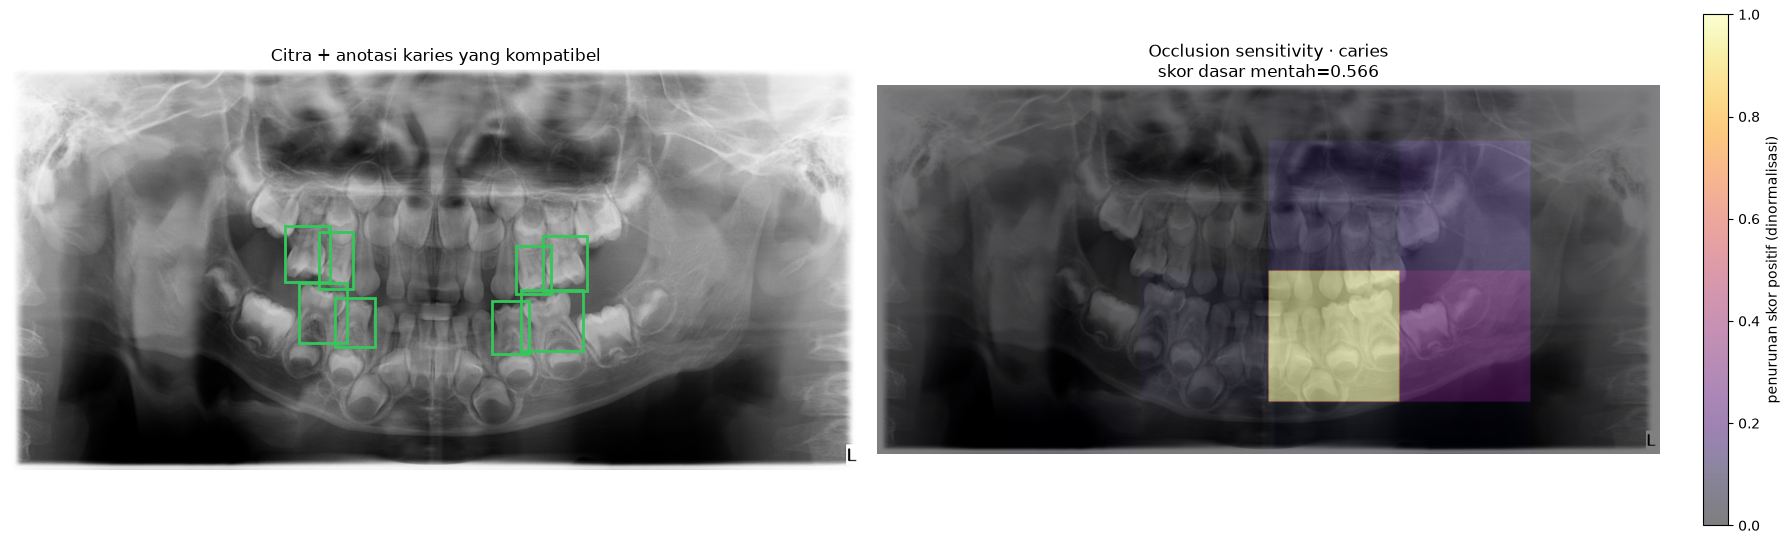

Rentang perubahan skor (dasar − setelah ditutup): -0.0009 s.d. 0.1574


In [50]:
if not all(name in globals() for name in ("DETECTOR", "image_rgb", "OCCLUSION_GRID")):
    raise RuntimeError("Urutan sel belum lengkap. Pilih Runtime → Run all.")

if DETECTOR is not None:
    print(
        f"Memulai analisis occlusion sensitivity (grid={OCCLUSION_GRID}; "
        f"{OCCLUSION_GRID * OCCLUSION_GRID} inferensi tambahan)..."
    )
    OCCLUSION_RESULT = occlusion_sensitivity(
        DETECTOR, image_rgb, target_class="caries", grid_size=OCCLUSION_GRID
    )
    show_occlusion(image_rgb, OCCLUSION_RESULT, _case_annotations(case_info))
else:
    print("Mode FALLBACK aktif: occlusion sensitivity dilewati.")
    print("Heatmap memerlukan inferensi langsung ke model untuk menghitung perubahan skor per petak.")
    canonical_note = (
        "Pada kasus test_cate1_004, inferensi langsung menunjukkan penurunan skor terbesar "
        "terkonsentrasi di regio gigi molar sulung bawah tempat karies berada."
    )
    print("Catatan temuan kanonis:", canonical_note)
    if "OCCLUSION_RESULT" in globals() and OCCLUSION_RESULT is not None:
        show_occlusion(
            image_rgb, OCCLUSION_RESULT, _case_annotations(case_info)
        )

### 🩺 Diskusikan — Prinsip Membaca *Heatmap* secara Kritis dan Aman

Visualisasi peta panas (*heatmap*) sering kali disalahartikan sebagai "bukti pemikiran" model. Sebagai klinisi radiologi, kita wajib bersikap skeptis dan memahami batasan teknisnya:

- **Sensitivitas Respon, Bukan Pemahaman Medis:** Peta panas ini semata-mata menunjukkan sensitivitas skor model terhadap pola penutupan piksel yang kita tentukan, bukan pemahaman biologis mengenai proses patologi gigi.
- **Dampak Ukuran Kisi (*Grid Size*):** Ukuran kisi yang lebih lebar (misalnya 4×4) menutup area yang terlalu luas sehingga kehilangan detail batas lesi. Sebaliknya, kisi yang lebih rapat (misalnya 8×8) memberikan detail spasial yang lebih tinggi dan membutuhkan komputasi lebih banyak, namun dapat memunculkan pola visual yang berbeda.
- **Area Panas di Luar Batas Lesi:** Jika area hangat muncul di luar batas kelainan (misalnya pada struktur tulang sehat atau mahkota tiruan), hal itu dapat dipicu oleh fitur konteks di sekitar gigi atau sekadar artefak tepi dari kotak penutup.
- **Bukan Penjelasan Kausal:** Area panas yang berimpit dengan lesi belum membuktikan bahwa model mengenali tanda radiografis yang sahih. Kotak prediksi bukan penjelasan kausal; visualisasi *heatmap* **bukan bukti lesi** dan sama sekali bukan jaminan validitas model klinis.

> **Uji Stabilitas Penjelasan:** Cobalah membandingkan ukuran grid 4, 6, dan 8 pada sel kode di atas. Jika kesimpulan visual Anda berubah secara drastis hanya karena ukuran grid diubah, hal itu menunjukkan bahwa penjelasan model tersebut bersifat tidak stabil (*fragile*) dan tidak boleh dijadikan dasar keyakinan klinis.

### ✅ Checkpoint Teknis — Validasi Integritas Koordinat, Visualisasi, dan Penanganan Label

Sel verifikasi otomatis untuk memastikan tipe data citra, dimensi array, rentang koordinat kotak deteksi, validitas keluaran evaluasi, serta kestabilan nilai numerik *heatmap* telah memenuhi kriteria teknis praktikum.

In [51]:
assert image_rgb.dtype == np.uint8
assert image_rgb.ndim == 3 and image_rgb.shape[2] == 3
for pred in predictions:
    x1, y1, x2, y2 = pred["bbox_xyxy"]
    assert 0.0 <= x1 < x2 <= image_rgb.shape[1]
    assert 0.0 <= y1 < y2 <= image_rgb.shape[0]
    assert 0.0 <= pred["score"] <= 1.0

assert evaluation["tp"] >= 0 and evaluation["fp"] >= 0 and evaluation["fn"] >= 0
assert isinstance(evaluation["matches"], list)
assert isinstance(evaluation["unscorable_ground_truth"], list)
assert isinstance(evaluation["unscorable_predictions"], list)

if "OCCLUSION_RESULT" in globals() and OCCLUSION_RESULT is not None:
    grid = OCCLUSION_RESULT["heatmap_grid"]
    heatmap = OCCLUSION_RESULT["heatmap_original"]
    assert grid.shape == (OCCLUSION_GRID, OCCLUSION_GRID)
    assert heatmap.shape == image_rgb.shape[:2]
    assert np.isfinite(heatmap).all()
print("Checkpoint teknis lulus.")

Checkpoint teknis lulus.


## Prinsip Penerapan AI yang Bertanggung Jawab dan Pengawasan Manusia (*Human Oversight*)

Dalam mengadopsi teknologi kecerdasan artifisial di ranah kedokteran gigi, dokter spesialis radiologi memegang kendali penuh sebagai pengawas utama (*human-in-the-loop*):

- **Mencegah Bias Otomatisasi (*Automation Bias*):** Biasakan untuk selalu memeriksa dan mencatat hasil pengamatan radiograf secara mandiri terlebih dahulu. Tampilkan hasil prediksi model AI hanya sebagai opini pembanding kedua (*second opinion*).
- **Kepatuhan Privasi Data Medis (*Cloud Privacy*):** **Jangan unggah data atau radiograf pasien riil ke Google Colab** maupun layanan *cloud* publik tanpa regulasi tata kelola data klinis, persetujuan etik (*ethical clearance*), *informed consent*, dan perjanjian perlindungan data institusi yang sah. Dalam praktikum ini, kita secara disiplin hanya menggunakan berkas kasus publik berlisensi resmi.
- **Kewenangan dan Tanggung Jawab Dokter (*Human Oversight*):** Dokter pemeriksa bertanggung jawab penuh untuk menilai mutu teknis citra, menginterpretasi temuan klinis di luar ruang label model, serta mengantisipasi dampak dari hasil positif palsu maupun negatif palsu. Perangkat lunak AI tidak pernah menggantikan kompetensi, intuisi, dan tanggung jawab hukum seorang radiolog.
- **Kebutuhan Validasi Klinis Lokal:** Model yang dilaporkan memiliki akurasi tinggi pada dataset publik belum tentu andal saat diterapkan pada populasi rumah sakit kita. Uji validasi lokal yang independen, analisis subkelompok pasien, serta pemantauan pergeseran performa secara berkala (*drift monitoring*) wajib dilakukan sebelum model digunakan dalam alur kerja nyata.
- **Transparansi Asal-Usul Data (*Provenance*) dan Lisensi:** Selalu lakukan audit terhadap hak penggunaan data, izin lisensi model, serta pustaka pendukung sebelum mengadopsi atau menyebarluaskan sistem AI.

> **Kaidah Praktis Klinis:** Apabila Anda tidak dapat menjelaskan asal-usul data pelatihannya, cakupan ruang labelnya, versi spesifik model yang digunakan, tahapan pra-pemrosesan citranya, nilai ambang batasnya, serta batasan evaluasinya, maka keluaran dari model AI tersebut **belum layak dijadikan dasar pertimbangan tindakan medis**.

## Tiket Keluar (*Exit Ticket*) — Refleksi Mandiri Akhir Sesi

Sebagai evaluasi mandiri sebelum menyelesaikan sesi praktikum ini, tuliskan jawaban singkat dan terarah untuk empat pertanyaan berikut:

1. Perubahan konkret apa yang Anda amati pada jumlah dan letak kotak deteksi ketika nilai `CONF_THRESHOLD` dinaikkan dari 0,25 menjadi 0,45?
2. Sebutkan satu label kelainan yang tidak dapat dievaluasi pada praktikum hari ini, dan jelaskan mengapa label tersebut tidak boleh dimasukkan ke dalam perhitungan False Positive (FP) atau False Negative (FN).
3. Jelaskan makna dari kemunculan satu area berwarna hangat/terang pada visualisasi *occlusion sensitivity*, serta sebutkan kesimpulan klinis apa yang **tidak boleh** diambil dari tampilan tersebut.
4. Uraikan satu risiko klinis penerapan model deteksi dewasa pada radiograf OPG anak (*pediatric*), serta jelaskan satu tindakan pengawasan dokter (*human oversight*) yang wajib dilakukan untuk mengendalikannya.

**Kriteria Keberhasilan Jawaban:** Berikan penjelasan yang spesifik merujuk pada konsep data latih, batasan model, atau nilai parameter yang kita uji hari ini, bukan sekadar pernyataan umum seperti *"model AI bisa salah"*.

## Glosarium Istilah Praktikum

| Istilah | Definisi Operasional dalam Praktikum |
|---|---|
| **Bounding box** | Kotak batas koordinat `[x1, y1, x2, y2]` yang melingkupi perkiraan posisi dan ukuran objek kelainan pada citra. |
| **Confidence threshold** | Nilai ambang batas skor keyakinan model; kandidat deteksi dengan skor di bawah nilai ini akan disaring dan diabaikan. |
| **Non-Maximum Suppression (NMS)** | Algoritma penapisan untuk mengeliminasi kotak-kotak deteksi berlebih yang saling bertumpuk pada objek yang sama. |
| **Intersection over Union (IoU)** | Rasio matematis antara luas area irisan (*intersection*) dibagi luas area gabungan (*union*) dari dua kotak pembatas. |
| **TP / FP / FN** | Klasifikasi hasil evaluasi (*True Positive*, *False Positive*, *False Negative*) yang membandingkan kotak prediksi terhadap anotasi acuan berdasarkan kriteria IoU dan kesetaraan label. |
| **Label space** | Ruang atau daftar himpunan kelas kelainan yang telah dipelajari model dan mampu dikenali dalam prediksinya. |
| **Domain shift** | Perbedaan karakteristik antara distribusi data latih model dan populasi data di lingkungan praktik klinis nyata. |
| **Occlusion sensitivity** | Metode evaluasi *Explainable AI* yang mengukur signifikansi area citra dengan cara menutup petak piksel secara bertahap dan mengamati penurunan skor model. |
| **Fallback** | Berkas keluaran deteksi acuan yang telah disimpan sebelumnya untuk memandu jalannya diskusi ketika koneksi internet terkendala; bukan hasil inferensi langsung pada sesi saat ini. |
| **Human oversight** | Pengawasan dan kendali penuh dokter pemeriksa atas kelayakan data masukan, interpretasi keluaran model, serta pengambilan keputusan klinis akhir. |

## Sumber Rujukan dan Batasan Penggunaan

- **Dataset Terbuka:** [Children’s Dental Panoramic Radiographs Dataset (Figshare)](https://springernature.figshare.com/articles/dataset/Children_s_Dental_Panoramic_Radiographs_Dataset/21621705)
- **Publikasi Metodologi Data:** [Scientific Data, DOI: 10.1038/s41597-023-02237-5](https://doi.org/10.1038/s41597-023-02237-5)
- **Artefak Model Deteksi Eksternal:** [liodon-ai/dental-panoramic-detector](https://huggingface.co/liodon-ai/dental-panoramic-detector)
- **Pustaka Komputasi Inferensi:** [ONNX Runtime](https://onnxruntime.ai/)

> **Pernyataan Penafian Etis & Batasan Teknis:**  
> Seluruh materi, kode program, dan citra di dalam notebook ini disusun semata-mata untuk keperluan pendidikan akademis dan audit teknis non-klinis. Empat kasus radiograf anak yang diuji tidak merepresentasikan keanekaragaman seluruh populasi pasien secara luas. Keluaran dari notebook ini tidak boleh digunakan sebagai panduan keputusan klinis maupun rencana perawatan medis pasien. Praktikum ini membutuhkan koneksi internet untuk pengunduhan awal aset dan bobot model, kecuali fasilitator/pengajar telah menyediakan folder aset lokal di lingkungan belajar Anda.